<a href="https://colab.research.google.com/github/command404/production_line_optimisation/blob/main/Production_line_optimisation_CLEANED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Production Line Optimisation — Manufacturing Intelligence Platform
Cleaned build notebook. Produces all saved model artifacts used by the Streamlit app (`app.py` / `agents.py`). Run top to bottom once per fresh Drive setup; after artifacts are saved to Drive, most sessions only need Setup + the specific section you're editing.

## 0. Setup — mount Drive, install packages, locate data files

In [18]:
# CELL 1 — mount Drive and define paths
from google.colab import drive
drive.mount('/content/drive')
import os
BASE = '/content/drive/MyDrive/mfg_ai'
for d in ['raw','processed','models','db','outputs']:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [19]:
# CELL 2 — install extras (Colab already has torch, sklearn, pandas)
!pip -q install simpy shap lightgbm xgboost gradio faiss-cpu sentence-transformers ortools h5py

In [20]:
import glob, os

# search all of /content (and Drive) for the CSVs and the image folders
csv_hits = glob.glob('/content/**/Model_*.csv', recursive=True) + \
           glob.glob('/content/drive/MyDrive/**/Model_*.csv', recursive=True)
print("CSV files found:")
for p in csv_hits: print("  ", p)

img_hits = glob.glob('/content/**/crack', recursive=True) + \
           glob.glob('/content/drive/MyDrive/**/crack', recursive=True)
print("\nImage 'crack' folders found:")
for p in img_hits: print("  ", p)

CSV files found:
   /content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_2.csv
   /content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_1.csv
   /content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_3.csv
   /content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_2.csv
   /content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_1.csv
   /content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_3.csv

Image 'crack' folders found:
   /content/drive/MyDrive/train/crack
   /content/drive/MyDrive/train/crack


In [21]:
csvs = {os.path.basename(p): p for p in csv_hits}
print(csvs)   # should show Model_1.csv, Model_2.csv, Model_3.csv

IMG = os.path.dirname(img_hits[0])       # the folder that contains crack/, hole/, etc.
SIM = os.path.dirname(os.path.dirname(csvs['Model_1.csv']))
print("IMG:", IMG)
print("SIM:", SIM)

{'Model_2.csv': '/content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_2.csv', 'Model_1.csv': '/content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_1.csv', 'Model_3.csv': '/content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model_3.csv'}
IMG: /content/drive/MyDrive/train
SIM: /content/drive/MyDrive


In [22]:
# CELL 4 — load the 3 production datasets, clean, save as parquet
import pandas as pd
SIM = '/content/data/sim/Manufacturing Data Shared Facility - Discrete-Event Simulation'

m1 = pd.read_csv(csvs['Model_1.csv'])
m1 = m1.loc[:, ~m1.columns.str.startswith('Unnamed')]
m2 = pd.read_csv(csvs['Model_2.csv'])
m3 = pd.read_csv(csvs['Model_3.csv'])

for name, df in [('m1',m1),('m2',m2),('m3',m3)]:
    df.columns = df.columns.str.strip()
    df.to_parquet(f'{BASE}/processed/{name}.parquet')
    print(name, df.shape, '| nulls:', int(df.isna().sum().sum()))

display(m1.describe().T.head(12))
display(m3.iloc[:, :12].describe().T)

m1 (3000, 10) | nulls: 0
m2 (3000, 17) | nulls: 0
m3 (605620, 78) | nulls: 37


,count,mean,std,min,25%,50%,75%,max
Demand,3000.0,10.442000,5.524504,1.000000,6.000000,10.000000,15.000000,20.000000
Total parts,3000.0,5025.625333,2669.628454,431.000000,2752.500000,4995.000000,7345.500000,10811.000000
Parts per hour,3000.0,209.453333,111.240475,18.000000,115.000000,208.000000,306.000000,450.000000
VA Time,3000.0,8.999680,0.013369,8.924635,8.991825,8.999643,9.007459,9.091995
Drilling Waiting Time,3000.0,31.158644,54.503320,0.000000,0.174507,2.150659,33.947769,257.618175
Milling Waiting Time,3000.0,0.000046,0.000057,0.000000,0.000000,0.000026,0.000074,0.000390
Assembly Waiting Time,3000.0,97.115862,101.900932,0.000000,0.675814,42.488235,219.586275,244.006984
Drilling Util,3000.0,0.648810,0.308589,0.059771,0.382142,0.692557,0.975251,0.999999
Milling Util,3000.0,0.485562,0.230931,0.044539,0.285355,0.518271,0.730265,0.752147
Assembly Util,3000.0,0.775912,0.287112,0.088929,0.570478,0.978921,0.995886,0.996373


,count,mean,std,min,25%,50%,75%,max
Time_Now,605620.0,24.000000,0.000000,24.000000,24.000000,24.000000,24.000000,24.000000
Blanking_Util,605620.0,0.852569,0.007207,0.827566,0.847539,0.852566,0.857595,0.877753
Blanking_SKU1_Queue,605620.0,0.047028,0.006596,0.017861,0.042510,0.046888,0.051420,0.083648
Blanking_SKU2_Queue,605620.0,0.047006,0.006602,0.019112,0.042474,0.046856,0.051385,0.085950
Blanking_SKU3_Queue,605620.0,0.047044,0.006601,0.018628,0.042521,0.046903,0.051419,0.078455
Blanking_SKU4_Queue,605620.0,0.047005,0.006592,0.019761,0.042475,0.046852,0.051382,0.081267
Press1_Util,605620.0,0.435534,0.048329,0.243365,0.402294,0.434463,0.467647,0.681753
Press2_Util,605620.0,0.435970,0.048388,0.232906,0.402790,0.435040,0.468167,0.696314
Press3_Util,605620.0,0.436798,0.048441,0.220103,0.403354,0.435526,0.468853,0.694798
Press4_Util,605620.0,0.436698,0.048416,0.233854,0.403344,0.435505,0.468818,0.683588


In [23]:
import glob, os

# find every folder named "crack" and pick the one that holds PNGs
hits = [p for p in glob.glob('/content/**/crack', recursive=True) if glob.glob(f'{p}/*.png')]
print("crack folders with images:", hits)

IMG = os.path.dirname(hits[0])     # the folder that contains crack/, hole/, normal/, rust/, scratch/
print("IMG =", IMG)
print(sorted(os.listdir(IMG)))

crack folders with images: ['/content/drive/MyDrive/train/crack']
IMG = /content/drive/MyDrive/train
['crack', 'hole', 'normal', 'rust', 'scratch']


{'crack': 2400, 'hole': 2400, 'normal': 2400, 'rust': 2400, 'scratch': 2400}
(256, 256)


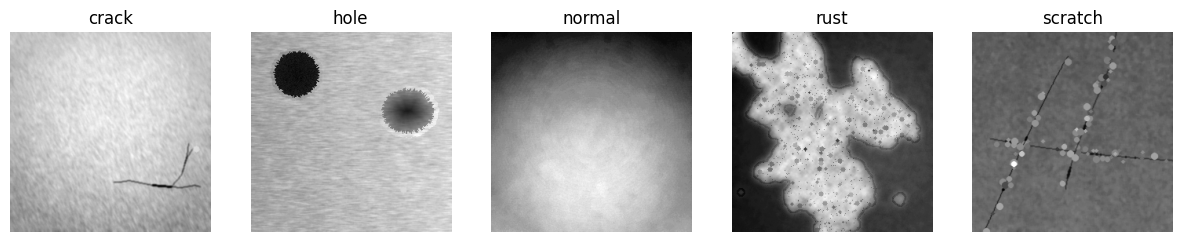

In [24]:
from PIL import Image
import matplotlib.pyplot as plt

classes = ['crack', 'hole', 'normal', 'rust', 'scratch']
counts = {c: len(glob.glob(f'{IMG}/{c}/*.png')) for c in classes}
print(counts)   # expect 2400 each
print(Image.open(glob.glob(f'{IMG}/crack/*.png')[0]).size)   # expect (256, 256)

fig, ax = plt.subplots(1, 5, figsize=(15, 3))
for a, c in zip(ax, classes):
    a.imshow(Image.open(glob.glob(f'{IMG}/{c}/*.png')[0]), cmap='gray')
    a.set_title(c); a.axis('off')
plt.show()

In [25]:
import glob, os

mat_hits = glob.glob('/content/**/3000Samplesv3.mat', recursive=True)
mz_hits  = glob.glob('/content/**/Matlab Models.zip', recursive=True)
pdf_hits = glob.glob('/content/**/Model 3.pdf', recursive=True)

print("mat:", mat_hits)
print("matlab zip:", mz_hits)
print("model 3 pdf:", pdf_hits)

mat: ['/content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/3000Samplesv3.mat']
matlab zip: ['/content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Matlab Models.zip']
model 3 pdf: ['/content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/Model 3/Model 3.pdf']


## 1. Quality Agent — defect classification (5-class ResNet18) + novelty detection
Trains on 4 known classes with `rust` held out to validate novel-defect detection, then retrains on all 5 classes for the production model. Saves `quality_resnet18_final.pt` + `quality_agent_meta.json` (class order, OOD energy threshold).

In [26]:
import torch
print(torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NO GPU')

True Tesla T4


In [27]:
#cell 13
import numpy as np, glob, random
from PIL import Image
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
KNOWN = ['normal', 'crack', 'hole', 'scratch']
NOVEL = 'rust'          # held out on purpose; change it if you want a different "unknown"
SIZE = 128

def load_class(c):
    files = sorted(glob.glob(f'{IMG}/{c}/*.png'))
    return np.stack([np.array(Image.open(f).convert('L').resize((SIZE, SIZE), Image.BILINEAR)) for f in files])

Xs, ys = [], []
for i, c in enumerate(KNOWN):
    a = load_class(c); Xs.append(a); ys += [i] * len(a)
X, y = np.concatenate(Xs), np.array(ys)

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=SEED)
X_va, X_te, y_va, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED)
X_nov = load_class(NOVEL)
print('train', X_tr.shape, '| val', X_va.shape, '| test', X_te.shape, '| held-out', NOVEL, X_nov.shape)

train (6720, 128, 128) | val (1440, 128, 128) | test (1440, 128, 128) | held-out rust (2400, 128, 128)


In [28]:
#cell 14
import torch, torch.nn as nn, torch.nn.functional as F, random
from torchvision import models
dev = 'cuda' if torch.cuda.is_available() else 'cpu'

class PretrainedQuality(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        net = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)   # ImageNet pretrained
        net.fc = nn.Identity()                                           # keep the 512-d embedding
        self.backbone = net
        self.head = nn.Linear(512, n_classes)
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std',  torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))
    def embed(self, x):                        # x: N x 1 x H x W in [0, 1]
        x = x.expand(-1, 3, -1, -1)            # grayscale -> 3 channels
        return self.backbone((x - self.mean) / self.std)
    def forward(self, x):
        return self.head(self.embed(x))

# data helpers (same as before)
to_t = lambda a: torch.from_numpy(a).unsqueeze(1)
Xtr_t, Xva_t, Xte_t, Xnov_t = map(to_t, [X_tr, X_va, X_te, X_nov])
ytr_t, yva_t, yte_t = [torch.from_numpy(v).long() for v in (y_tr, y_va, y_te)]

def batches(X, y=None, bs=128, shuffle=False):
    idx = torch.randperm(len(X)) if shuffle else torch.arange(len(X))
    for i in range(0, len(X), bs):
        j = idx[i:i + bs]
        xb = X[j].to(dev).float() / 255.
        yield xb if y is None else (xb, y[j].to(dev))

model = PretrainedQuality(len(KNOWN)).to(dev)
EPOCHS = 8
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, epochs=EPOCHS,
                                            steps_per_epoch=(len(Xtr_t) + 127) // 128)
scaler = torch.amp.GradScaler(enabled=(dev == 'cuda'))

for ep in range(EPOCHS):
    model.train(); tot = 0
    for xb, yb in batches(Xtr_t, ytr_t, shuffle=True):
        if random.random() < 0.5: xb = xb.flip(3)
        if random.random() < 0.5: xb = xb.flip(2)
        with torch.autocast(device_type=dev, dtype=torch.float16, enabled=(dev == 'cuda')):
            loss = F.cross_entropy(model(xb), yb)
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        tot += loss.item() * len(xb)
    model.eval(); correct = 0
    with torch.no_grad():
        for xb, yb in batches(Xva_t, yva_t):
            correct += (model(xb).argmax(1) == yb).sum().item()
    print(f'epoch {ep+1}/{EPOCHS}  train loss {tot/len(Xtr_t):.4f}  val acc {correct/len(Xva_t):.3f}')

torch.save(model.state_dict(), f'{BASE}/models/quality_resnet18.pt')

/tmp/ipykernel_4309/4221867643.py:47: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()


epoch 1/8  train loss 0.4005  val acc 1.000
epoch 2/8  train loss 0.0022  val acc 1.000
epoch 3/8  train loss 0.0013  val acc 1.000
epoch 4/8  train loss 0.0006  val acc 1.000
epoch 5/8  train loss 0.0003  val acc 1.000
epoch 6/8  train loss 0.0002  val acc 1.000
epoch 7/8  train loss 0.0002  val acc 1.000
epoch 8/8  train loss 0.0002  val acc 1.000


              precision    recall  f1-score   support

      normal      1.000     1.000     1.000       360
       crack      1.000     1.000     1.000       360
        hole      1.000     1.000     1.000       360
     scratch      1.000     1.000     1.000       360

    accuracy                          1.000      1440
   macro avg      1.000     1.000     1.000      1440
weighted avg      1.000     1.000     1.000      1440



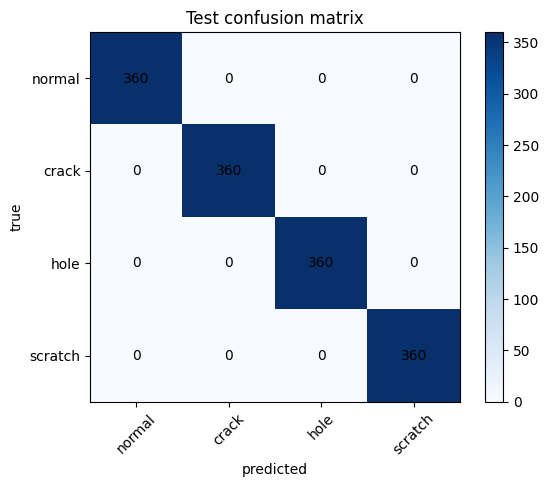

In [29]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

def get_logits(X):
    model.eval(); out = []
    with torch.no_grad():
        for xb in batches(X):
            out.append(model(xb).float().cpu())
    return torch.cat(out)

lg_te = get_logits(Xte_t)
pred = lg_te.argmax(1).numpy()
print(classification_report(y_te, pred, target_names=KNOWN, digits=3))

cm = confusion_matrix(y_te, pred)
plt.imshow(cm, cmap='Blues'); plt.colorbar()
plt.xticks(range(4), KNOWN, rotation=45); plt.yticks(range(4), KNOWN)
for i in range(4):
    for j in range(4):
        plt.text(j, i, cm[i, j], ha='center', va='center')
plt.xlabel('predicted'); plt.ylabel('true'); plt.title('Test confusion matrix'); plt.show()

In [30]:
from sklearn.metrics import roc_auc_score

lg_va, lg_nov = get_logits(Xva_t), get_logits(Xnov_t)
score_fns = {'Max-softmax': lambda lg: F.softmax(lg, 1).max(1).values.numpy(),
             'Energy':      lambda lg: torch.logsumexp(lg, 1).numpy()}

for name, fn in score_fns.items():
    s_va, s_te, s_nov = fn(lg_va), fn(lg_te), fn(lg_nov)
    thr = np.percentile(s_va, 5)
    auroc = roc_auc_score(np.r_[np.ones(len(s_te)), np.zeros(len(s_nov))], np.r_[s_te, s_nov])
    print(f'{name:12s} AUROC={auroc:.3f} | known images wrongly flagged: {np.mean(s_te < thr):.1%} '
          f'| {NOVEL} flagged as novel: {np.mean(s_nov < thr):.1%}')

Max-softmax  AUROC=0.999 | known images wrongly flagged: 4.7% | rust flagged as novel: 99.6%
Energy       AUROC=0.999 | known images wrongly flagged: 4.5% | rust flagged as novel: 99.6%


In [31]:
# Combine the existing 4-class split with a matching 70/15/15 split of the held-out rust images
# to build the final 5-class split, without re-reading any PNGs from disk.
import numpy as np

KNOWN5 = ['normal', 'crack', 'hole', 'scratch', 'rust']
rust_label = 4  # index of 'rust' in KNOWN5

rng = np.random.RandomState(SEED)
n_nov = len(X_nov)
perm = rng.permutation(n_nov)
n_tr = int(round(0.70 * n_nov))
n_va = int(round(0.15 * n_nov))
idx_tr, idx_va, idx_te = perm[:n_tr], perm[n_tr:n_tr+n_va], perm[n_tr+n_va:]

Xr_tr, Xr_va, Xr_te = X_nov[idx_tr], X_nov[idx_va], X_nov[idx_te]
yr_tr = np.full(len(idx_tr), rust_label, dtype=y_tr.dtype)
yr_va = np.full(len(idx_va), rust_label, dtype=y_va.dtype)
yr_te = np.full(len(idx_te), rust_label, dtype=y_te.dtype)

X_tr5 = np.concatenate([X_tr, Xr_tr]); y_tr5 = np.concatenate([y_tr, yr_tr])
X_va5 = np.concatenate([X_va, Xr_va]); y_va5 = np.concatenate([y_va, yr_va])
X_te5 = np.concatenate([X_te, Xr_te]); y_te5 = np.concatenate([y_te, yr_te])

# shuffle train so batches are mixed-class, not rust-appended-at-the-end
shuf = rng.permutation(len(X_tr5))
X_tr5, y_tr5 = X_tr5[shuf], y_tr5[shuf]

print('5-class split:', X_tr5.shape, X_va5.shape, X_te5.shape)
print('class counts (train):', np.bincount(y_tr5))

np.savez('/content/quality_split_final.npz',
         X_tr=X_tr5, y_tr=y_tr5, X_va=X_va5, y_va=y_va5, X_te=X_te5, y_te=y_te5)
print('saved /content/quality_split_final.npz')

5-class split: (8400, 128, 128) (1800, 128, 128) (1800, 128, 128)
class counts (train): [1680 1680 1680 1680 1680]
saved /content/quality_split_final.npz


In [32]:
# Same architecture/training loop as Cell 14, now for all 5 known classes (final production model).
import torch, torch.nn as nn, torch.nn.functional as F, random

model5 = PretrainedQuality(len(KNOWN5)).to(dev)

to_t = lambda a: torch.from_numpy(a).unsqueeze(1)
Xtr5_t, Xva5_t, Xte5_t = map(to_t, [X_tr5, X_va5, X_te5])
ytr5_t, yva5_t, yte5_t = [torch.from_numpy(v).long() for v in (y_tr5, y_va5, y_te5)]

EPOCHS = 8
opt = torch.optim.AdamW(model5.parameters(), lr=3e-4, weight_decay=1e-4)
sched = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, epochs=EPOCHS, steps_per_epoch=(len(Xtr5_t) + 127) // 128)
scaler = torch.amp.GradScaler(enabled=(dev == 'cuda'))

for ep in range(EPOCHS):
    model5.train(); tot = 0
    for xb, yb in batches(Xtr5_t, ytr5_t, shuffle=True):
        if random.random() < 0.5: xb = xb.flip(3)
        if random.random() < 0.5: xb = xb.flip(2)
        with torch.autocast(device_type=dev, dtype=torch.float16, enabled=(dev == 'cuda')):
            loss = F.cross_entropy(model5(xb), yb)
        opt.zero_grad(); scaler.scale(loss).backward(); scaler.step(opt); scaler.update(); sched.step()
        tot += loss.item() * len(xb)
    model5.eval(); correct = 0
    with torch.no_grad():
        for xb, yb in batches(Xva5_t, yva5_t):
            correct += (model5(xb).argmax(1) == yb).sum().item()
    print(f'epoch {ep+1}/{EPOCHS}  train loss {tot/len(Xtr5_t):.4f}  val acc {correct/len(Xva5_t):.3f}')

torch.save(model5.state_dict(), f'{BASE}/models/quality_resnet18_final.pt')
print('saved final model')

epoch 1/8  train loss 0.3832  val acc 0.999
epoch 2/8  train loss 0.0041  val acc 0.997
epoch 3/8  train loss 0.0014  val acc 1.000
epoch 4/8  train loss 0.0014  val acc 1.000
epoch 5/8  train loss 0.0003  val acc 1.000
epoch 6/8  train loss 0.0012  val acc 1.000
epoch 7/8  train loss 0.0003  val acc 1.000
epoch 8/8  train loss 0.0004  val acc 1.000
saved final model


In [33]:
# Classification report on the 5-class test set, plus a fresh OOD/uncertainty threshold
# calibrated on THIS model's own validation set (for flagging genuinely new defect types later).
import json
from sklearn.metrics import classification_report, confusion_matrix

def get_logits5(X):
    model5.eval()
    outs = []
    with torch.no_grad():
        for xb in batches(X, bs=128):
            outs.append(model5(xb).cpu())
    return torch.cat(outs)

logits_te = get_logits5(Xte5_t)
preds_te = logits_te.argmax(1).numpy()
print(classification_report(y_te5, preds_te, target_names=KNOWN5))
print('confusion matrix:\n', confusion_matrix(y_te5, preds_te))

# energy score on validation set -> 5th percentile threshold for "novel/uncertain"
logits_va = get_logits5(Xva5_t)
energy_va = torch.logsumexp(logits_va, dim=1).numpy()
ood_threshold = float(np.percentile(energy_va, 5))

meta = {
    'class_order': KNOWN5,
    'ood_score_method': 'energy_logsumexp',
    'ood_threshold': ood_threshold,
    'threshold_definition': '5th percentile of validation energy scores; scores below this are flagged Novel/uncertain defect'
}
with open(f'{BASE}/models/quality_agent_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)
print(meta)

              precision    recall  f1-score   support

      normal       1.00      1.00      1.00       360
       crack       1.00      1.00      1.00       360
        hole       1.00      1.00      1.00       360
     scratch       1.00      1.00      1.00       360
        rust       1.00      1.00      1.00       360

    accuracy                           1.00      1800
   macro avg       1.00      1.00      1.00      1800
weighted avg       1.00      1.00      1.00      1800

confusion matrix:
 [[360   0   0   0   0]
 [  0 360   0   0   0]
 [  0   0 360   0   0]
 [  0   0   0 360   0]
 [  0   0   0   0 360]]
{'class_order': ['normal', 'crack', 'hole', 'scratch', 'rust'], 'ood_score_method': 'energy_logsumexp', 'ood_threshold': 7.15764856338501, 'threshold_definition': '5th percentile of validation energy scores; scores below this are flagged Novel/uncertain defect'}


# **Image Classification Model**


Saving hairline-crack-wall.webp to hairline-crack-wall.webp


/tmp/ipykernel_4309/838641769.py:44: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  confidence = float(probs[pred_idx])


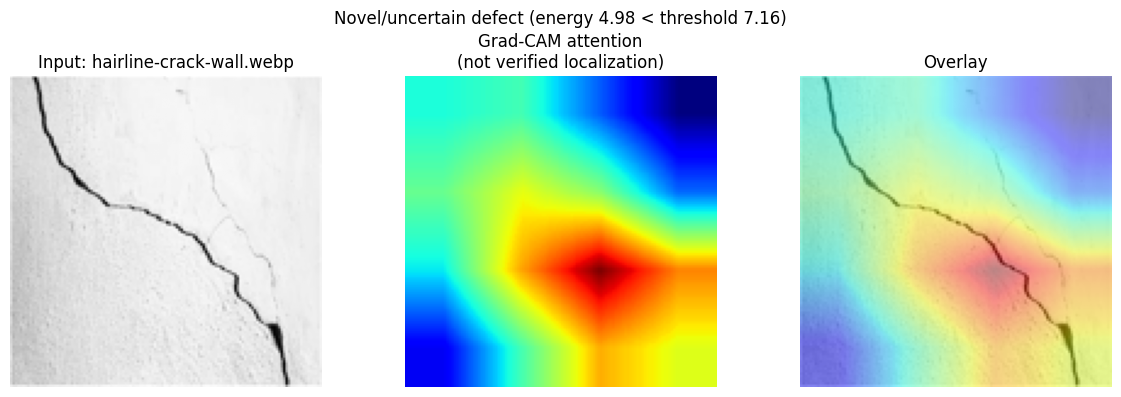

Per-class probabilities: {'normal': 0.0018, 'crack': 0.9937, 'hole': 0.0007, 'scratch': 0.0031, 'rust': 0.0006}
Novelty flag: True | energy score: 4.983 | threshold: 7.158


In [34]:
# Upload any image, run it through the final 5-class model, report prediction + confidence,
# flag as "Novel/uncertain defect" if the energy score falls below the calibrated threshold,
# and show a Grad-CAM heatmap labeled as attention evidence (not verified localization,
# since the dataset has no bounding-box/mask ground truth to measure against).

import json, io
import numpy as np
import torch
import torch.nn.functional as F
from PIL import Image
import matplotlib.pyplot as plt
from google.colab import files

with open(f'{BASE}/models/quality_agent_meta.json') as f:
    meta = json.load(f)
CLASS_ORDER = meta['class_order']
OOD_THRESHOLD = meta['ood_threshold']

# --- Grad-CAM hook setup (last conv block of the ResNet18 backbone) ---
_gc_activations = {}
_gc_gradients = {}

def _fwd_hook(module, inp, out):
    _gc_activations['value'] = out.detach()

def _bwd_hook(module, grad_in, grad_out):
    _gc_gradients['value'] = grad_out[0].detach()

target_layer = model5.backbone.layer4  # last conv block, best spatial resolution before pooling
h1 = target_layer.register_forward_hook(_fwd_hook)
h2 = target_layer.register_full_backward_hook(_bwd_hook)

def predict_and_gradcam(pil_img):
    model5.eval()
    img = pil_img.convert('L').resize((128, 128))
    arr = np.array(img, dtype=np.float32) / 255.
    x = torch.from_numpy(arr).unsqueeze(0).unsqueeze(0).to(dev)  # 1 x 1 x 128 x 128
    x.requires_grad_(False)

    logits = model5(x)
    probs = F.softmax(logits, dim=1)[0]
    pred_idx = int(probs.argmax())
    pred_class = CLASS_ORDER[pred_idx]
    confidence = float(probs[pred_idx])

    energy = float(torch.logsumexp(logits, dim=1)[0])
    is_novel = energy < OOD_THRESHOLD

    # backward pass for Grad-CAM, on the predicted class's logit
    model5.zero_grad()
    logits[0, pred_idx].backward()

    acts = _gc_activations['value'][0]        # C x h x w
    grads = _gc_gradients['value'][0]          # C x h x w
    weights = grads.mean(dim=(1, 2))           # C
    cam = F.relu((weights.view(-1, 1, 1) * acts).sum(0))
    cam = cam.cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
    cam_resized = np.array(Image.fromarray((cam * 255).astype(np.uint8)).resize((128, 128), Image.BILINEAR)) / 255.

    return pred_class, confidence, is_novel, energy, arr, cam_resized, dict(zip(CLASS_ORDER, probs.tolist()))

# --- upload + run ---
uploaded = files.upload()
for fname, content in uploaded.items():
    pil_img = Image.open(io.BytesIO(content))
    pred_class, confidence, is_novel, energy, arr, cam, all_probs = predict_and_gradcam(pil_img)

    label = f"Novel/uncertain defect (energy {energy:.2f} < threshold {OOD_THRESHOLD:.2f})" if is_novel \
            else f"{pred_class}  (confidence {confidence:.1%})"

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(arr, cmap='gray'); axes[0].set_title(f'Input: {fname}'); axes[0].axis('off')
    axes[1].imshow(cam, cmap='jet'); axes[1].set_title('Grad-CAM attention\n(not verified localization)'); axes[1].axis('off')
    axes[2].imshow(arr, cmap='gray'); axes[2].imshow(cam, cmap='jet', alpha=0.45); axes[2].set_title('Overlay'); axes[2].axis('off')
    plt.suptitle(label)
    plt.tight_layout(); plt.show()

    print('Per-class probabilities:', {k: round(v, 4) for k, v in all_probs.items()})
    print('Novelty flag:', is_novel, '| energy score:', round(energy, 3), '| threshold:', round(OOD_THRESHOLD, 3))

h1.remove(); h2.remove()  # clean up hooks so they don't stack on rerun

## 2. Production Agent — bottleneck detector (generic across factory layouts)
`score_stages()` is factory-independent: same function, only `stage_config` changes per model. Tested unchanged on Model 1, 2, and 3 (the generality proof point).

In [35]:
# Load Model 1, 2, 3 tables — prefer cached parquet (faster on slow network), fall back to CSV.
import glob, os
import pandas as pd

def load_model(name, csv_glob):
    parquet_path = f'{BASE}/processed/{name}.parquet'
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
        print(f'{name}: loaded from parquet, shape {df.shape}')
        return df
    hits = glob.glob(f'/content/**/{csv_glob}', recursive=True)
    if not hits:
        raise FileNotFoundError(f'No CSV matching {csv_glob} found under /content')
    df = pd.read_csv(hits[0])
    df = df.loc[:, ~df.columns.str.startswith('Unnamed')]  # drop empty Unnamed cols (Model 1 has 12)
    os.makedirs(f'{BASE}/processed', exist_ok=True)
    df.to_parquet(parquet_path)
    print(f'{name}: loaded from CSV ({hits[0]}), cached to parquet, shape {df.shape}')
    return df

m1 = load_model('m1', 'Model_1.csv')
m2 = load_model('m2', 'Model_2.csv')
m3 = load_model('m3', 'Model_3.csv')

m1: loaded from parquet, shape (3000, 10)
m2: loaded from parquet, shape (3000, 17)
m3: loaded from parquet, shape (605620, 78)


In [36]:
# The bottleneck table showed Cell1-4 and Paint1-2 queue means as 0.000 — check whether that's
# real (waiting is recorded elsewhere, e.g. Warehouse_N queues) or a column-name mismatch.
queue_cols = [c for c in m3.columns if 'Queue' in c or 'queue' in c]
print('All queue-related columns in Model 3:')
print(queue_cols)
print()
for c in queue_cols:
    print(f'{c:35s} mean={m3[c].mean():.3f}  max={m3[c].max():.3f}  nonzero%={(m3[c] > 0).mean()*100:.1f}%')

All queue-related columns in Model 3:
['Blanking_SKU1_Queue', 'Blanking_SKU2_Queue', 'Blanking_SKU3_Queue', 'Blanking_SKU4_Queue', 'Press1_Queue', 'Press2_Queue', 'Press3_Queue', 'Press4_Queue', 'Cell1_Queue', 'Cell2_Queue', 'Cell3_Queue', 'Cell4_Queue', 'Warehouse1_Queue', 'Warehouse_2_Queue', 'Warehouse_3_Queue', 'Warehouse_4_Queue', 'Paint1_Queue', 'Paint2_Queue', 'Quality_Queue', 'Forklift_Blanking_Queue', 'Forklift_Press_Queue', 'Forklift_Assembly_Queue', 'Blanking_Queue']

Blanking_SKU1_Queue                 mean=0.047  max=0.084  nonzero%=100.0%
Blanking_SKU2_Queue                 mean=0.047  max=0.086  nonzero%=100.0%
Blanking_SKU3_Queue                 mean=0.047  max=0.078  nonzero%=100.0%
Blanking_SKU4_Queue                 mean=0.047  max=0.081  nonzero%=100.0%
Press1_Queue                        mean=72.296  max=297.821  nonzero%=100.0%
Press2_Queue                        mean=62.923  max=225.594  nonzero%=100.0%
Press3_Queue                        mean=54.236  max=221.390

In [37]:
# Generic bottleneck scorer. Takes a dataframe + a list of stage configs and scores every
# stage the same way, regardless of which factory it came from. Only the stage_config list
# differs per model -- this function must not change between Model 1/2/3.
#
# Score components (each 0-1, weighted composite):
#   - saturation: mean utilization, blended with how often it crosses 0.9 (captures spikes
#     that a mean alone would smooth over)
#   - queue_pressure: this stage's own queue, normalized against the largest queue value
#     seen in this factory's config (so scores are comparable within one factory's stages).
#     If no reliable queue column exists for a stage, this component is skipped and the
#     stage is flagged low_confidence rather than guessing a value.
#   - starvation: if any declared upstream stage is highly saturated (>0.85 mean util) while
#     THIS stage's own utilization is comparatively low, this stage may be starved of work
#     rather than bottlenecked -- flagged separately, not folded into the main score, since
#     starvation is the opposite problem from a bottleneck.
#
# This is intentionally simple and transparent (no black-box ML here) so every score is
# traceable back to raw columns -- matches the "no unsupported LLM-invented numbers" principle.

import pandas as pd
import numpy as np

def score_stages(df: pd.DataFrame, stage_config: list[dict]) -> pd.DataFrame:
    """
    stage_config: list of dicts, each:
      {
        'stage': 'Cell1',                  # display name
        'util_col': 'Cell1',                # utilization column name
        'queue_col': 'Cell1_Queue' or None, # queue column name, or None if unreliable/unavailable
        'upstream': ['Blanking'],           # list of stage names feeding this one
      }
    Returns one row per stage with saturation, queue_pressure, composite score, starvation flag,
    and a confidence note.
    """
    # first pass: compute raw util means per stage (needed for starvation checks)
    util_means = {}
    for s in stage_config:
        if s['util_col'] in df.columns:
            util_means[s['stage']] = df[s['util_col']].mean()

    # queue scale: normalize each stage's queue against the max mean queue seen in this factory
    queue_means = {}
    for s in stage_config:
        if s['queue_col'] and s['queue_col'] in df.columns:
            queue_means[s['stage']] = df[s['queue_col']].mean()
    max_queue = max(queue_means.values()) if queue_means else 1.0

    rows = []
    for s in stage_config:
        stage, util_col, queue_col = s['stage'], s['util_col'], s.get('queue_col')
        if util_col not in df.columns:
            rows.append({'stage': stage, 'note': f'util_col {util_col} not found in data'})
            continue

        util = df[util_col]
        util_mean = util.mean()
        frac_saturated = (util > 0.9).mean()
        saturation = 0.7 * util_mean + 0.3 * frac_saturated  # blend mean + spike frequency

        has_queue = queue_col is not None and queue_col in df.columns and df[queue_col].mean() > 0
        if has_queue:
            queue_pressure = min(1.0, queue_means[stage] / max_queue)
            confidence = 'normal'
        else:
            queue_pressure = np.nan
            confidence = 'low (no reliable queue data for this stage)'

        # starvation check: any upstream stage highly saturated while this stage runs cool
        starved = False
        starving_upstream = []
        for up in s.get('upstream', []):
            if up in util_means and util_means[up] > 0.85 and util_mean < 0.5:
                starved = True
                starving_upstream.append(up)

        composite = saturation if np.isnan(queue_pressure) else (0.6 * saturation + 0.4 * queue_pressure)

        rows.append({
            'stage': stage,
            'util_mean': round(util_mean, 3),
            'frac_time_saturated_gt_0.9': round(frac_saturated, 3),
            'queue_pressure_normalized': round(queue_pressure, 3) if has_queue else None,
            'composite_bottleneck_score': round(composite, 3),
            'possibly_starved': starved,
            'starved_by_upstream': starving_upstream if starved else None,
            'confidence': confidence,
        })

    return pd.DataFrame(rows).sort_values('composite_bottleneck_score', ascending=False).reset_index(drop=True)

In [38]:
#cell 24
# Model 1: linear line Drilling -> Milling -> Assembly.
# No literal queue-count column exists here -- Waiting Time columns are used as a
# time-based proxy for queue pressure (more waiting time ~ more queued work, per
# Little's Law), NOT the same unit as Model 3's queue counts. Normalization is done
# per-factory inside score_stages, so mixing proxy types across factories is safe.
stage_config_m1 = [
    {'stage': 'Drilling', 'util_col': 'Drilling Util', 'queue_col': 'Drilling Waiting Time', 'upstream': []},
    {'stage': 'Milling',  'util_col': 'Milling Util',  'queue_col': 'Milling Waiting Time',  'upstream': ['Drilling']},
    {'stage': 'Assembly', 'util_col': 'Assembly Util', 'queue_col': 'Assembly Waiting Time', 'upstream': ['Milling']},
]

# Model 2: same linear line, columns literally named "Queue Time" (still a time proxy,
# not a literal count, but more directly named as queue-related than Model 1's).
stage_config_m2 = [
    {'stage': 'Drilling', 'util_col': 'Drilling Utilization', 'queue_col': 'Drilling Queue Time', 'upstream': []},
    {'stage': 'Milling',  'util_col': 'Milling Utilization',  'queue_col': 'Milling Queue Time',  'upstream': ['Drilling']},
    {'stage': 'Assembly', 'util_col': 'Assembly Utilization', 'queue_col': 'Assembly Queue Time', 'upstream': ['Milling']},
]


In [39]:
# Fix: Model 3's utilization columns all carry a "_Util" suffix, confirmed by Cell 25a.
# Also hardening score_stages so a genuine mismatch produces a visible NaN row instead
# of silently omitting 'composite_bottleneck_score' and crashing sort_values downstream.

stage_config_m3 = [
    {'stage': 'Blanking', 'util_col': 'Blanking_Util', 'queue_col': 'Blanking_Queue', 'upstream': []},
    {'stage': 'Forklift',  'util_col': 'Forklift_Util', 'queue_col': 'Forklift_Total_Queue', 'upstream': ['Blanking']},
    {'stage': 'Press1', 'util_col': 'Press1_Util', 'queue_col': 'Press1_Queue', 'upstream': ['Forklift']},
    {'stage': 'Press2', 'util_col': 'Press2_Util', 'queue_col': 'Press2_Queue', 'upstream': ['Forklift']},
    {'stage': 'Press3', 'util_col': 'Press3_Util', 'queue_col': 'Press3_Queue', 'upstream': ['Forklift']},
    {'stage': 'Press4', 'util_col': 'Press4_Util', 'queue_col': 'Press4_Queue', 'upstream': ['Forklift']},
    {'stage': 'Cell1', 'util_col': 'Cell1_Util', 'queue_col': None, 'upstream': ['Press1', 'Press2', 'Press3', 'Press4']},
    {'stage': 'Cell2', 'util_col': 'Cell2_Util', 'queue_col': None, 'upstream': ['Press1', 'Press2', 'Press3', 'Press4']},
    {'stage': 'Cell3', 'util_col': 'Cell3_Util', 'queue_col': None, 'upstream': ['Press1', 'Press2', 'Press3', 'Press4']},
    {'stage': 'Cell4', 'util_col': 'Cell4_Util', 'queue_col': None, 'upstream': ['Press1', 'Press2', 'Press3', 'Press4']},
    {'stage': 'Paint1', 'util_col': 'Paint1_Util', 'queue_col': None, 'upstream': ['Cell1', 'Cell2', 'Cell3', 'Cell4']},
    {'stage': 'Paint2', 'util_col': 'Paint2_Util', 'queue_col': None, 'upstream': ['Cell1', 'Cell2', 'Cell3', 'Cell4']},
    {'stage': 'Quality', 'util_col': 'Quality_Util', 'queue_col': 'Quality_Queue', 'upstream': ['Paint1', 'Paint2']},
]

# Harden score_stages: a missing util_col now yields a NaN-scored row (visible in output,
# won't crash sort_values) instead of a bare {'stage','note'} dict.
def score_stages(df: pd.DataFrame, stage_config: list[dict]) -> pd.DataFrame:
    util_means = {}
    for s in stage_config:
        if s['util_col'] in df.columns:
            util_means[s['stage']] = df[s['util_col']].mean()

    queue_means = {}
    for s in stage_config:
        if s['queue_col'] and s['queue_col'] in df.columns:
            queue_means[s['stage']] = df[s['queue_col']].mean()
    max_queue = max(queue_means.values()) if queue_means else 1.0

    rows = []
    for s in stage_config:
        stage, util_col, queue_col = s['stage'], s['util_col'], s.get('queue_col')
        if util_col not in df.columns:
            rows.append({
                'stage': stage, 'util_mean': np.nan, 'frac_time_saturated_gt_0.9': np.nan,
                'queue_pressure_normalized': None, 'composite_bottleneck_score': np.nan,
                'possibly_starved': False, 'starved_by_upstream': None,
                'confidence': f'ERROR: util_col "{util_col}" not found in data',
            })
            continue

        util = df[util_col]
        util_mean = util.mean()
        frac_saturated = (util > 0.9).mean()
        saturation = 0.7 * util_mean + 0.3 * frac_saturated

        has_queue = queue_col is not None and queue_col in df.columns and df[queue_col].mean() > 0
        if has_queue:
            queue_pressure = min(1.0, queue_means[stage] / max_queue)
            confidence = 'normal'
        else:
            queue_pressure = np.nan
            confidence = 'low (no reliable queue data for this stage)'

        starved = False
        starving_upstream = []
        for up in s.get('upstream', []):
            if up in util_means and util_means[up] > 0.85 and util_mean < 0.5:
                starved = True
                starving_upstream.append(up)

        composite = saturation if np.isnan(queue_pressure) else (0.6 * saturation + 0.4 * queue_pressure)

        rows.append({
            'stage': stage,
            'util_mean': round(util_mean, 3),
            'frac_time_saturated_gt_0.9': round(frac_saturated, 3),
            'queue_pressure_normalized': round(queue_pressure, 3) if has_queue else None,
            'composite_bottleneck_score': round(composite, 3),
            'possibly_starved': starved,
            'starved_by_upstream': starving_upstream if starved else None,
            'confidence': confidence,
        })

    return pd.DataFrame(rows).sort_values('composite_bottleneck_score', ascending=False, na_position='last').reset_index(drop=True)

# rerun all three with the same unchanged function
results_m1 = score_stages(m1, stage_config_m1)
results_m2 = score_stages(m2, stage_config_m2)
results_m3 = score_stages(m3, stage_config_m3)

print('=== Model 1 bottleneck ranking ===')
print(results_m1.to_string(index=False))
print('\n=== Model 2 bottleneck ranking ===')
print(results_m2.to_string(index=False))
print('\n=== Model 3 bottleneck ranking ===')
print(results_m3.to_string(index=False))

=== Model 1 bottleneck ranking ===
   stage  util_mean  frac_time_saturated_gt_0.9  queue_pressure_normalized  composite_bottleneck_score  possibly_starved starved_by_upstream confidence
Assembly      0.776                       0.559                      1.000                       0.827             False                None     normal
Drilling      0.649                       0.334                      0.321                       0.461             False                None     normal
 Milling      0.486                       0.000                      0.000                       0.204             False                None     normal

=== Model 2 bottleneck ranking ===
   stage  util_mean  frac_time_saturated_gt_0.9  queue_pressure_normalized  composite_bottleneck_score  possibly_starved starved_by_upstream confidence
Drilling      0.521                       0.102                      1.000                       0.637             False                None     normal
Assembly      0.6

In [40]:
# Add saturation-only rank alongside the composite, so "most overloaded" and
# "most queue pressure" can be read as two distinct signals instead of blended
# into one number that hides which one is driving the result.

def add_dual_ranks(results: pd.DataFrame) -> pd.DataFrame:
    out = results.copy()
    out['saturation_rank'] = out['util_mean'].rank(ascending=False, method='min').astype('Int64')
    has_q = out['queue_pressure_normalized'].notna()
    out['queue_rank'] = pd.Series([pd.NA] * len(out), index=out.index, dtype='Int64')
    out.loc[has_q, 'queue_rank'] = out.loc[has_q, 'queue_pressure_normalized'].rank(ascending=False, method='min').astype('Int64')
    out['composite_rank'] = out['composite_bottleneck_score'].rank(ascending=False, method='min', na_option='bottom').astype('Int64')
    out['signals_agree'] = (out['saturation_rank'] == out['composite_rank']) | out['queue_rank'].isna()
    return out

r1 = add_dual_ranks(results_m1)
r2 = add_dual_ranks(results_m2)
r3 = add_dual_ranks(results_m3)

for name, r in [('Model 1', r1), ('Model 2', r2), ('Model 3', r3)]:
    print(f'=== {name}: composite vs saturation ranking ===')
    print(r[['stage', 'util_mean', 'frac_time_saturated_gt_0.9', 'queue_pressure_normalized',
              'saturation_rank', 'queue_rank', 'composite_rank', 'composite_bottleneck_score', 'confidence']].to_string(index=False))
    top_sat = r.loc[r['saturation_rank'] == 1, 'stage'].tolist()
    top_composite = r.loc[r['composite_rank'] == 1, 'stage'].tolist()
    if set(top_sat) != set(top_composite):
        print(f'>>> DISAGREEMENT: most-overloaded by raw utilization = {top_sat}, '
              f'top by blended composite (incl. queue evidence) = {top_composite}. '
              f'Report both as distinct findings rather than a single "the bottleneck" answer.')
    print()

=== Model 1: composite vs saturation ranking ===
   stage  util_mean  frac_time_saturated_gt_0.9  queue_pressure_normalized  saturation_rank  queue_rank  composite_rank  composite_bottleneck_score confidence
Assembly      0.776                       0.559                      1.000                1           1               1                       0.827     normal
Drilling      0.649                       0.334                      0.321                2           2               2                       0.461     normal
 Milling      0.486                       0.000                      0.000                3           3               3                       0.204     normal

=== Model 2: composite vs saturation ranking ===
   stage  util_mean  frac_time_saturated_gt_0.9  queue_pressure_normalized  saturation_rank  queue_rank  composite_rank  composite_bottleneck_score confidence
Drilling      0.521                       0.102                      1.000                2           1   

### Plain-language bottleneck summary
Findings only — no recommendation/fix text (recommendations require the Simulation + Economic + Recommendation agents to back them with real evidence).

In [41]:
# Trimmed: states findings only, no definitions of utilization/queue/starvation.
# Recommendations are intentionally NOT generated here -- see section 3/7: the LLM
# must not invent fixes without simulation + cost backing. Real recommendations come
# from roadmap steps 5 (Simulation Agent), 6 (Economic Agent), 9 (Recommendation Agent).

def explain_bottlenecks(ranked_df: pd.DataFrame, factory_name: str) -> str:
    df = ranked_df.copy()
    lines = [f"--- {factory_name} ---"]

    sat_leader_rows = df[df['saturation_rank'] == 1]
    queue_leader_rows = df[df['queue_rank'] == 1] if df['queue_rank'].notna().any() else pd.DataFrame()
    sat_leader = sat_leader_rows.iloc[0] if len(sat_leader_rows) else None
    queue_leader = queue_leader_rows.iloc[0] if len(queue_leader_rows) else None

    if sat_leader is not None:
        lines.append(f"Overload: {sat_leader['stage']} ({sat_leader['util_mean']*100:.0f}% util, {sat_leader['frac_time_saturated_gt_0.9']*100:.0f}% of runs >90%).")

    if queue_leader is not None and (sat_leader is None or queue_leader['stage'] != sat_leader['stage']):
        lines.append(f"Queue pile-up: {queue_leader['stage']} (score {queue_leader['queue_pressure_normalized']:.2f}/1.0).")
    elif queue_leader is not None:
        lines.append(f"Overload and queue pile-up both point to {sat_leader['stage']}.")

    no_queue_data = df[df['confidence'].astype(str).str.contains('low', na=False)]['stage'].tolist()
    if sat_leader is not None and sat_leader['stage'] in no_queue_data:
        lines.append(f"{sat_leader['stage']}: no queue data available, score is utilization-only.")

    starved = df[df['possibly_starved'] == True]
    for _, row in starved.iterrows():
        lines.append(f"Possible starvation: {row['stage']} ({row['util_mean']*100:.0f}% util) — upstream {row['starved_by_upstream']} saturated.")

    return '\n'.join(lines)

print(explain_bottlenecks(r1, 'Model 1'))
print()
print(explain_bottlenecks(r2, 'Model 2'))
print()
print(explain_bottlenecks(r3, 'Model 3'))

--- Model 1 ---
Overload: Assembly (78% util, 56% of runs >90%).
Overload and queue pile-up both point to Assembly.

--- Model 2 ---
Overload: Assembly (68% util, 40% of runs >90%).
Queue pile-up: Drilling (score 1.00/1.0).

--- Model 3 ---
Overload: Cell1 (87% util, 13% of runs >90%).
Queue pile-up: Press1 (score 1.00/1.0).
Cell1: no queue data available, score is utilization-only.
Possible starvation: Paint1 (48% util) — upstream ['Cell1'] saturated.


## 3. Model 3 `.mat` file — verified structure
Confirms `Predictors`/`Responses`/`Model3Predictors`/`Model3Answer*` map exactly onto the CSV's cell×SKU routing counters — this mapping is the basis for the demand regressors below.

In [42]:
import scipy.io as sio
import numpy as np

mat = sio.loadmat(mat_hits[0])

for key in ['Predictors', 'Model3Predictors', 'Regression', 'Responses']:
    if key in mat:
        arr = mat[key]
        print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")
        print(f"  first 3 rows:\n{arr[:3]}")
        print(f"  col mins: {arr.min(axis=0)}")
        print(f"  col maxs: {arr.max(axis=0)}")
        print()

candidate_cols = [c for c in m3.columns if any(k in c for k in
    ['Demand', 'SKU', 'Total', 'c_Total', 'v_Demand'])]
print("Candidate M3 columns to check:", candidate_cols)
print(m3[candidate_cols].head(3) if candidate_cols else "none found")

/usr/local/lib/python3.13/dist-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


Predictors: shape=(605620, 4), dtype=uint16
  first 3 rows:
[[13967 14621 16450 13650]
 [15071 15458 13408 15224]
 [16603 15144 14421 11984]]
  col mins: [8251 8049 7454 8005]
  col maxs: [21299 23940 23693 23182]

Model3Predictors: shape=(3000, 4), dtype=uint16
  first 3 rows:
[[13394 18182 14555 14130]
 [14381 15748 12941 16229]
 [13259 15695 16152 14720]]
  col mins: [ 9485 10094  9917  9585]
  col maxs: [20403 20935 21080 21600]

Regression: shape=(605620, 12), dtype=uint16
  first 3 rows:
[[13967 14621 16450 13650 10867  4382  2851  4334   903  4707 11743  4934]
 [15071 15458 13408 15224 11180  3615  2932  4125  1346  3852  9556  7484]
 [16603 15144 14421 11984 11042  2260  2904  4149  1198  4139 10282  5575]]
  col mins: [8251 8049 7454 8005 6011    0 1574 2454   88 2140 5314 1387]
  col maxs: [21299 23940 23693 23182 17355 10114  4483  6762  2473  6776 16917 11935]

Responses: shape=(605620, 8), dtype=uint16
  first 3 rows:
[[10867  4382  2851  4334   903  4707 11743  4934]
 [11

In [43]:
import numpy as np

pred = mat['Predictors']

# 1. Confirm col 0 == c_Cell1_SKU1 across ALL rows, not just the first 3
col0_match = np.array_equal(m3['c_Cell1_SKU1'].values.astype(np.uint16), pred[:, 0])
print("Predictors col0 == c_Cell1_SKU1 (all 605620 rows):", col0_match)

# 2. Per Model 3 process flow: SKU2->Cells1/2/3, SKU3->Cells3/4, SKU4->Cells1/2/4
sku2_cols = ['c_Cell1__SKU2', 'c_Cell2__SKU2', 'c_Cell3__SKU2']
sku3_cols = ['c_Cell3__SKU3', 'c_Cell4__SKU3']
sku4_cols = ['c_Cell1__SKU4', 'c_Cell2__SKU4', 'c_Cell4__SKU4']

sku2_sum = m3[sku2_cols].sum(axis=1).values
sku3_sum = m3[sku3_cols].sum(axis=1).values
sku4_sum = m3[sku4_cols].sum(axis=1).values

for label, s in [('SKU2_sum', sku2_sum), ('SKU3_sum', sku3_sum), ('SKU4_sum', sku4_sum)]:
    for col in range(4):
        corr = np.corrcoef(s, pred[:, col])[0, 1]
        exact = np.allclose(s, pred[:, col], atol=0.5)
        print(f"{label} vs Predictors col{col}: corr={corr:.4f}, near-exact={exact}")

Predictors col0 == c_Cell1_SKU1 (all 605620 rows): True
SKU2_sum vs Predictors col0: corr=-0.3043, near-exact=False
SKU2_sum vs Predictors col1: corr=1.0000, near-exact=True
SKU2_sum vs Predictors col2: corr=-0.2907, near-exact=False
SKU2_sum vs Predictors col3: corr=-0.2857, near-exact=False
SKU3_sum vs Predictors col0: corr=-0.2830, near-exact=False
SKU3_sum vs Predictors col1: corr=-0.2907, near-exact=False
SKU3_sum vs Predictors col2: corr=1.0000, near-exact=True
SKU3_sum vs Predictors col3: corr=-0.2906, near-exact=False
SKU4_sum vs Predictors col0: corr=-0.2872, near-exact=False
SKU4_sum vs Predictors col1: corr=-0.2857, near-exact=False
SKU4_sum vs Predictors col2: corr=-0.2906, near-exact=False
SKU4_sum vs Predictors col3: corr=1.0000, near-exact=True


In [44]:
# Responses is 8 columns. We know Responsec1s2/c1s4/c2s2/c2s4/c3s2/c3s3/c4s3/c4s4
# exist as separate .mat variables (per section 8) — that's 8 names, matching count.
resp_names_order = ['Responsec1s2', 'Responsec1s4', 'Responsec2s2', 'Responsec2s4',
                     'Responsec3s2', 'Responsec3s3', 'Responsec4s3', 'Responsec4s4']

resp = mat['Responses']
for i, name in enumerate(resp_names_order):
    if name in mat:
        individual = mat[name].flatten()
        match = np.array_equal(individual.astype(np.uint16), resp[:, i])
        corr = np.corrcoef(individual, resp[:, i])[0, 1]
        print(f"Responses col{i} vs {name}: exact_match={match}, corr={corr:.4f}")
    else:
        print(f"{name} not found in mat")

Responses col0 vs Responsec1s2: exact_match=True, corr=1.0000
Responses col1 vs Responsec1s4: exact_match=True, corr=1.0000
Responses col2 vs Responsec2s2: exact_match=True, corr=1.0000
Responses col3 vs Responsec2s4: exact_match=True, corr=1.0000
Responses col4 vs Responsec3s2: exact_match=True, corr=1.0000
Responses col5 vs Responsec3s3: exact_match=True, corr=1.0000
Responses col6 vs Responsec4s3: exact_match=True, corr=1.0000
Responses col7 vs Responsec4s4: exact_match=True, corr=1.0000


In [45]:
answer_names_order = ['Model3Answerc1s2', 'Model3Answerc1s4', 'Model3Answerc2s2', 'Model3Answerc2s4',
                       'Model3Answerc3s2', 'Model3Answerc3s3', 'Model3Answerc4s3', 'Model3Answerc4s4']

print("Model3Predictors shape:", mat['Model3Predictors'].shape)
for name in answer_names_order:
    print(f"{name}: shape={mat[name].shape}, dtype={mat[name].dtype}, "
          f"min={mat[name].min()}, max={mat[name].max()}")

# Sanity check: do Model3Answer ranges look like they're on the same scale as
# the full Responses columns (i.e. actual counts), or something else (e.g. normalized)?
print()
print("For comparison, full Responses column ranges:")
for i, name in enumerate(resp_names_order):
    print(f"  Responses col{i} ({name}): min={resp[:,i].min()}, max={resp[:,i].max()}")

Model3Predictors shape: (3000, 4)
Model3Answerc1s2: shape=(3000, 1), dtype=float64, min=7378.006824633927, max=15387.280810524699
Model3Answerc1s4: shape=(3000, 1), dtype=float64, min=222.51285079473303, max=8569.09235757164
Model3Answerc2s2: shape=(3000, 1), dtype=float64, min=1947.5920744289892, max=3998.705903386675
Model3Answerc2s4: shape=(3000, 1), dtype=float64, min=3326.584547905303, max=6240.242220020847
Model3Answerc3s2: shape=(3000, 1), dtype=float64, min=395.72863273092213, max=1953.176799475387
Model3Answerc3s3: shape=(3000, 1), dtype=float64, min=2849.707074083374, max=6031.5939631063775
Model3Answerc4s3: shape=(3000, 1), dtype=float64, min=7067.505781260406, max=15048.665680444648
Model3Answerc4s4: shape=(3000, 1), dtype=float64, min=2642.3955781111626, max=10404.599125610945

For comparison, full Responses column ranges:
  Responses col0 (Responsec1s2): min=6011, max=17355
  Responses col1 (Responsec1s4): min=0, max=10114
  Responses col2 (Responsec2s2): min=1574, max=44

## 4. Demand → cell/SKU routing-throughput regressor
Trained on the organizer's 3,000-row baseline set (`Model3Predictors`/`Model3Answer*`), matching their fitnet architecture (10 hidden neurons). Near-perfect fit is expected on deterministic simulation data — confirmed via train/test and full-605k-row validation, not just asserted.

In [46]:
import numpy as np
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

X = mat['Model3Predictors'].astype(np.float64)  # (3000, 4)
Y = np.hstack([mat[name] for name in answer_names_order])  # (3000, 8)
print("X shape:", X.shape, "Y shape:", Y.shape)

# 70/15/15 split, matching the organizer's baseline split ratio
X_train, X_temp, Y_train, Y_temp = train_test_split(X, Y, test_size=0.30, random_state=42)
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.50, random_state=42)
print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Scale inputs and outputs (neural nets train far better on standardized data;
# MATLAB's fitnet does this internally by default, so this matches its behavior)
x_scaler = StandardScaler().fit(X_train)
y_scaler = StandardScaler().fit(Y_train)

X_train_s = x_scaler.transform(X_train)
X_val_s = x_scaler.transform(X_val)
X_test_s = x_scaler.transform(X_test)

Y_train_s = y_scaler.transform(Y_train)
Y_val_s = y_scaler.transform(Y_val)
Y_test_s = y_scaler.transform(Y_test)

# 10 hidden neurons, matching the organizer's fitnet architecture
model = MLPRegressor(hidden_layer_sizes=(10,), activation='tanh',
                      solver='lbfgs', max_iter=2000, random_state=42)
model.fit(X_train_s, Y_train_s)

# Evaluate per output column
Y_test_pred_s = model.predict(X_test_s)
Y_test_pred = y_scaler.inverse_transform(Y_test_pred_s)

print(f"\n{'Output':<15}{'R2':>8}{'RMSE':>12}")
for i, name in enumerate(answer_names_order):
    r2 = r2_score(Y_test[:, i], Y_test_pred[:, i])
    rmse = np.sqrt(mean_squared_error(Y_test[:, i], Y_test_pred[:, i]))
    print(f"{name:<15}{r2:>8.4f}{rmse:>12.2f}")

X shape: (3000, 4) Y shape: (3000, 8)
Train: (2100, 4) Val: (450, 4) Test: (450, 4)

Output               R2        RMSE
Model3Answerc1s2  1.0000        8.50
Model3Answerc1s4  0.9998       16.22
Model3Answerc2s2  0.9999        2.28
Model3Answerc2s4  0.9997        7.20
Model3Answerc3s2  0.9998        3.26
Model3Answerc3s3  0.9999        4.78
Model3Answerc4s3  0.9999        9.66
Model3Answerc4s4  0.9997       17.90


In [47]:
Y_train_pred_s = model.predict(X_train_s)
Y_train_pred = y_scaler.inverse_transform(Y_train_pred_s)

print(f"{'Output':<15}{'Train R2':>10}{'Test R2':>10}")
for i, name in enumerate(answer_names_order):
    r2_tr = r2_score(Y_train[:, i], Y_train_pred[:, i])
    r2_te = r2_score(Y_test[:, i], Y_test_pred[:, i])
    print(f"{name:<15}{r2_tr:>10.4f}{r2_te:>10.4f}")

Output           Train R2   Test R2
Model3Answerc1s2    1.0000    1.0000
Model3Answerc1s4    0.9998    0.9998
Model3Answerc2s2    1.0000    0.9999
Model3Answerc2s4    0.9998    0.9997
Model3Answerc3s2    0.9998    0.9998
Model3Answerc3s3    0.9999    0.9999
Model3Answerc4s3    0.9999    0.9999
Model3Answerc4s4    0.9998    0.9997


In [48]:
import joblib, os
os.makedirs(f'{BASE}/models', exist_ok=True)
joblib.dump({'model': model, 'x_scaler': x_scaler, 'y_scaler': y_scaler,
             'output_names': answer_names_order},
            f'{BASE}/models/model3_demand_regressor.pkl')
print("saved.")

saved.


In [49]:
import joblib

saved = joblib.load(f'{BASE}/models/model3_demand_regressor.pkl')
model = saved['model']
x_scaler = saved['x_scaler']
y_scaler = saved['y_scaler']
output_names = saved['output_names']
print("Loaded. Output columns:", output_names)

Loaded. Output columns: ['Model3Answerc1s2', 'Model3Answerc1s4', 'Model3Answerc2s2', 'Model3Answerc2s4', 'Model3Answerc3s2', 'Model3Answerc3s3', 'Model3Answerc4s3', 'Model3Answerc4s4']


In [50]:
import numpy as np
import pandas as pd

# reuse X_test, Y_test from training if still in memory; otherwise rebuild
sample_idx = np.random.RandomState(0).choice(len(X_test), 5, replace=False)
X_sample = X_test[sample_idx]
Y_actual = Y_test[sample_idx]

X_sample_s = x_scaler.transform(X_sample)
Y_pred_s = model.predict(X_sample_s)
Y_pred = y_scaler.inverse_transform(Y_pred_s)

for i in range(5):
    print(f"\nDemand input: SKU1={X_sample[i,0]:.0f}, SKU2={X_sample[i,1]:.0f}, "
          f"SKU3={X_sample[i,2]:.0f}, SKU4={X_sample[i,3]:.0f}")
    df = pd.DataFrame({'Actual': Y_actual[i], 'Predicted': Y_pred[i]},
                       index=output_names)
    print(df.round(1))


Demand input: SKU1=16720, SKU2=15117, SKU3=12896, SKU4=13398
                   Actual  Predicted
Model3Answerc1s2  10936.4    10938.1
Model3Answerc1s4   2167.1     2169.8
Model3Answerc2s2   2879.1     2878.8
Model3Answerc2s4   4304.2     4308.8
Model3Answerc3s2   1301.1     1301.5
Model3Answerc3s3   3699.0     3697.0
Model3Answerc4s3   9197.0     9190.7
Model3Answerc4s4   6929.0     6939.3

Demand input: SKU1=13159, SKU2=15770, SKU3=16797, SKU4=14490
                   Actual  Predicted
Model3Answerc1s2  11746.2    11750.9
Model3Answerc1s4   4856.5     4863.3
Model3Answerc2s2   3065.1     3066.7
Model3Answerc2s4   4441.3     4442.0
Model3Answerc3s2    957.8      959.6
Model3Answerc3s3   4811.6     4812.9
Model3Answerc4s3  11985.4    11988.8
Model3Answerc4s4   5191.6     5198.0

Demand input: SKU1=14146, SKU2=17240, SKU3=13900, SKU4=15663
                   Actual  Predicted
Model3Answerc1s2  12580.0    12585.5
Model3Answerc1s4   3926.6     3917.1
Model3Answerc2s2   3282.5     3284.0


In [51]:
# Try a demand mix within the training range (min/max from section 8: ~7.4k-24k per SKU)
custom_demand = np.array([[15000, 15000, 12000, 13000]])
custom_demand_s = x_scaler.transform(custom_demand)
pred_s = model.predict(custom_demand_s)
pred = y_scaler.inverse_transform(pred_s)[0]

for name, val in zip(output_names, pred):
    print(f"{name}: {val:.0f}")

Model3Answerc1s2: 10808
Model3Answerc1s4: 2753
Model3Answerc2s2: 2853
Model3Answerc2s4: 3696
Model3Answerc3s2: 1370
Model3Answerc3s3: 3458
Model3Answerc4s3: 8582
Model3Answerc4s4: 6508


In [52]:
from sklearn.metrics import r2_score

X_full = mat['Predictors'].astype(np.float64)
Y_full = mat['Responses'].astype(np.float64)

X_full_s = x_scaler.transform(X_full)
Y_full_pred_s = model.predict(X_full_s)
Y_full_pred = y_scaler.inverse_transform(Y_full_pred_s)

print(f"{'Output':<15}{'R2 (full 605k set)':>20}")
for i, name in enumerate(output_names):
    r2 = r2_score(Y_full[:, i], Y_full_pred[:, i])
    print(f"{name:<15}{r2:>20.4f}")

Output           R2 (full 605k set)
Model3Answerc1s2              0.9954
Model3Answerc1s4              0.9406
Model3Answerc2s2              0.9943
Model3Answerc2s4              0.8734
Model3Answerc3s2              0.8332
Model3Answerc3s3              0.9997
Model3Answerc4s3              0.9999
Model3Answerc4s4              0.9250


## 5. SKU-level flow-efficiency view
Independently cross-validates the station-level bottleneck finding: SKU1 (routes only through Cell1) has by far the worst wait-time ratio of any SKU.

In [53]:
import pandas as pd
import numpy as np

sku_time_cols = {
    'SKU1': ['SKU1_VA_Time', 'SKU1_NVA_Time', 'SKU1_Transport_Time', 'SKU1_Wait_Time', 'SKU1_Other_Time'],
    'SKU2': ['SKU2_VA_Time', 'SKU2_NVA_Time', 'SKU2_Transport_Time', 'SKU2_Wait_Time', 'SKU2_Other_Time'],
    'SKU3': ['SKU3_VA_Time', 'SKU3_NVA_Time', 'SKU3_Transport_Time', 'SKU3_Wait_Time', 'SKU3_Other_Time'],
    'SKU4': ['SKU4_VA_Time', 'SKU4_NVA_Time', 'SKU4_Transport_Time', 'SKU4_Wait_Time', 'SKU4_Other_Time'],
}

rows = []
for sku, cols in sku_time_cols.items():
    means = m3[cols].mean()
    total = means.sum()
    row = {'SKU': sku}
    for c, val in means.items():
        component = c.replace(f'{sku}_', '').replace('_Time', '')
        row[component] = val
    row['Total_Cycle_Time'] = total
    row['VA_pct'] = 100 * means[f'{sku}_VA_Time'] / total if total > 0 else np.nan
    row['Wait_pct'] = 100 * means[f'{sku}_Wait_Time'] / total if total > 0 else np.nan
    rows.append(row)

sku_summary = pd.DataFrame(rows).sort_values('Wait_pct', ascending=False)
print(sku_summary.round(2))

    SKU    VA  NVA  Transport  Wait  Other  Total_Cycle_Time  VA_pct  Wait_pct
0  SKU1  1.53  0.0       0.54  0.72    0.0              2.79   54.75     26.00
2  SKU3  1.53  0.0       0.54  0.47    0.0              2.53   60.36     18.42
3  SKU4  1.52  0.0       0.54  0.46    0.0              2.52   60.46     18.26
1  SKU2  1.52  0.0       0.54  0.42    0.0              2.48   61.35     17.05


## 6. Production Agent — run-level anomaly detection (Isolation Forest)
Flags individual simulation runs that look statistically unusual across all 13 stations' utilization + queue columns — complementary to the averages-based bottleneck ranking above.

In [54]:
from sklearn.ensemble import IsolationForest
import numpy as np
import pandas as pd

# Use all utilization + queue features across the 13 Model 3 stations
# (reuse the same columns already used in stage_config_m3)
util_cols = [c for c in m3.columns if c.endswith('_Util')]
queue_cols = [c for c in m3.columns if c.endswith('_Queue')]
feature_cols = util_cols + queue_cols

print(f"Using {len(feature_cols)} features: {feature_cols}")

X_anom = m3[feature_cols].fillna(0).values

iso = IsolationForest(n_estimators=200, contamination=0.02, random_state=42, n_jobs=-1)
iso.fit(X_anom)

# anomaly_score: lower = more anomalous. is_anomaly: -1 = flagged, 1 = normal
anomaly_scores = iso.decision_function(X_anom)
is_anomaly = iso.predict(X_anom)

m3['anomaly_score'] = anomaly_scores
m3['is_anomaly'] = (is_anomaly == -1)

print(f"\nFlagged {m3['is_anomaly'].sum()} anomalous runs out of {len(m3)} "
      f"({100*m3['is_anomaly'].mean():.2f}%)")

# Show the 10 most anomalous runs
print("\nTop 10 most anomalous runs:")
print(m3.nsmallest(10, 'anomaly_score')[['anomaly_score'] + util_cols].round(3))

Using 36 features: ['Blanking_Util', 'Press1_Util', 'Press2_Util', 'Press3_Util', 'Press4_Util', 'Cell1_Util', 'Cell2_Util', 'Cell3_Util', 'Cell4_Util', 'Paint1_Util', 'Paint2_Util', 'Quality_Util', 'Forklift_Util', 'Blanking_SKU1_Queue', 'Blanking_SKU2_Queue', 'Blanking_SKU3_Queue', 'Blanking_SKU4_Queue', 'Press1_Queue', 'Press2_Queue', 'Press3_Queue', 'Press4_Queue', 'Cell1_Queue', 'Cell2_Queue', 'Cell3_Queue', 'Cell4_Queue', 'Warehouse1_Queue', 'Warehouse_2_Queue', 'Warehouse_3_Queue', 'Warehouse_4_Queue', 'Paint1_Queue', 'Paint2_Queue', 'Quality_Queue', 'Forklift_Blanking_Queue', 'Forklift_Press_Queue', 'Forklift_Assembly_Queue', 'Blanking_Queue']

Flagged 12113 anomalous runs out of 605620 (2.00%)

Top 10 most anomalous runs:
        anomaly_score  Blanking_Util  Press1_Util  Press2_Util  Press3_Util  \
84933          -0.141          0.844        0.600        0.448        0.318   
342043         -0.140          0.837        0.579        0.482        0.310   
316239         -0.138 

In [55]:
import joblib, os

os.makedirs(f'{BASE}/models', exist_ok=True)
joblib.dump({'model': iso, 'feature_cols': feature_cols, 'contamination': 0.02},
            f'{BASE}/models/production_anomaly_detector.pkl')
print("saved.")

saved.


In [56]:
def explain_anomalies(df, factory_name, feature_cols, top_n=5):
    flagged = df[df['is_anomaly']].copy()
    lines = [f"[{factory_name}] {len(flagged)} of {len(df)} runs flagged as anomalous "
             f"({100*len(flagged)/len(df):.1f}%)."]

    if len(flagged) == 0:
        return "\n".join(lines)

    # Which feature deviates most from the overall mean, per flagged run on average
    overall_mean = df[feature_cols].mean()
    flagged_mean = flagged[feature_cols].mean()
    deviation = (flagged_mean - overall_mean).abs().sort_values(ascending=False)
    top_driver = deviation.index[0]

    lines.append(f"Most distinguishing feature among anomalies: {top_driver} "
                 f"(avg {flagged_mean[top_driver]:.3f} vs overall avg {overall_mean[top_driver]:.3f}).")
    lines.append(f"Top {min(top_n, len(flagged))} most anomalous runs by score are available for engineer review; "
                 f"flagged runs should be treated as 'unusual, needs verification', not automatically defective.")
    return "\n".join(lines)

print(explain_anomalies(m3, "Model 3", feature_cols))

[Model 3] 12113 of 605620 runs flagged as anomalous (2.0%).
Most distinguishing feature among anomalies: Warehouse1_Queue (avg 341.536 vs overall avg 190.768).
Top 5 most anomalous runs by score are available for engineer review; flagged runs should be treated as 'unusual, needs verification', not automatically defective.


## 7. Simulation Agent — demand → utilization regressor
Data-driven replacement for the originally-planned SimPy simulator (SimPy hit an unresolved batch-size/arrival-rate contradiction — shelved, not fixed). This regressor is trained directly on the real 605,620-row dataset and gives near-instant what-if answers.

In [57]:
# Cell: load the .mat file and inspect what's actually inside
from scipy.io import loadmat

mat_path = '/content/drive/MyDrive/Manufacturing Data Shared Facility - Discrete-Event Simulation/3000Samplesv3.mat'
mat_hits = loadmat(mat_path)

# Show all keys and their shapes (skip internal __header__/__version__ etc.)
for k, v in mat_hits.items():
    if not k.startswith('__'):
        print(k, getattr(v, 'shape', type(v)))

/usr/local/lib/python3.13/dist-packages/scipy/io/matlab/_mio.py:235: MatReadWarning: Duplicate variable name "None" in stream - replacing previous with new
Considerscipy.io.matlab.varmats_from_mat to split file into single variable files
  matfile_dict = MR.get_variables(variable_names)


None (1,)
Model1Answer (3000, 3)
Model1Predictors (3000, 1)
Model1Response (3000, 3)
Model2AnswerAssembly (3000, 1)
Model2AnswerDrilling (3000, 1)
Model2AnswerMilling (3000, 1)
Model2PredictorAssembly (3000, 1)
Model2PredictorDrilling (3000, 2)
Model2PredictorMilling (3000, 2)
Model2ResponseAssembly (3000, 1)
Model2ResponseDrilling (3000, 1)
Model2ResponseMilling (3000, 1)
Model3Answerc1s2 (3000, 1)
Model3Answerc1s4 (3000, 1)
Model3Answerc2s2 (3000, 1)
Model3Answerc2s4 (3000, 1)
Model3Answerc3s2 (3000, 1)
Model3Answerc3s3 (3000, 1)
Model3Answerc4s3 (3000, 1)
Model3Answerc4s4 (3000, 1)
Model3Predictors (3000, 4)
Predictors (605620, 4)
Regression (605620, 12)
Responsec1s2 (605620, 1)
Responsec1s4 (605620, 1)
Responsec2s2 (605620, 1)
Responsec2s4 (605620, 1)
Responsec3s2 (605620, 1)
Responsec3s3 (605620, 1)
Responsec4s3 (605620, 1)
Responsec4s4 (605620, 1)
Responses (605620, 8)


In [58]:
# Cell: attach SKU demand (Predictors) to m3 by row position
predictors = mat_hits['Predictors']   # (605620, 4)
assert predictors.shape[0] == m3.shape[0], "Row count mismatch — do not proceed if this fails"

m3['SKU1_demand'] = predictors[:, 0]
m3['SKU2_demand'] = predictors[:, 1]
m3['SKU3_demand'] = predictors[:, 2]
m3['SKU4_demand'] = predictors[:, 3]

print(m3[['SKU1_demand', 'SKU2_demand', 'SKU3_demand', 'SKU4_demand']].describe())

         SKU1_demand    SKU2_demand    SKU3_demand    SKU4_demand
count  605620.000000  605620.000000  605620.000000  605620.000000
mean    14697.603099   14908.870751   14884.002414   14872.135884
std      1598.353717    1662.198312    1649.164162    1665.193135
min      8251.000000    8049.000000    7454.000000    8005.000000
25%     13600.000000   13764.000000   13745.000000   13728.000000
50%     14675.000000   14875.000000   14846.000000   14834.000000
75%     15771.000000   16012.000000   15980.000000   15976.000000
max     21299.000000   23940.000000   23693.000000   23182.000000


In [59]:
# Cell: retrain with proper feature scaling
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import numpy as np

util_cols = ['Blanking_Util', 'Press1_Util', 'Press2_Util', 'Press3_Util', 'Press4_Util',
             'Cell1_Util', 'Cell2_Util', 'Cell3_Util', 'Cell4_Util',
             'Paint1_Util', 'Paint2_Util', 'Quality_Util', 'Forklift_Util']

X = m3[['SKU1_demand', 'SKU2_demand', 'SKU3_demand', 'SKU4_demand']].values
y = m3[util_cols].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scale inputs to mean=0, std=1 -- this is the fix
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

demand_to_util = MLPRegressor(hidden_layer_sizes=(20, 10), activation='tanh',
                                solver='lbfgs', random_state=42, max_iter=2000)
demand_to_util.fit(X_train_scaled, y_train)

preds = demand_to_util.predict(X_test_scaled)
r2_per_station = {col: r2_score(y_test[:, i], preds[:, i]) for i, col in enumerate(util_cols)}
for col, r2 in sorted(r2_per_station.items(), key=lambda x: x[1]):
    print(f"{col:<15} R2 = {r2:.4f}")

print(f"\nOverall mean R2: {np.mean(list(r2_per_station.values())):.4f}")

Cell2_Util      R2 = 0.7691
Cell4_Util      R2 = 0.8525
Blanking_Util   R2 = 0.8798
Paint1_Util     R2 = 0.9085
Quality_Util    R2 = 0.9164
Paint2_Util     R2 = 0.9205
Forklift_Util   R2 = 0.9254
Cell1_Util      R2 = 0.9319
Cell3_Util      R2 = 0.9639
Press1_Util     R2 = 0.9722
Press4_Util     R2 = 0.9882
Press3_Util     R2 = 0.9884
Press2_Util     R2 = 0.9923

Overall mean R2: 0.9238


In [60]:
# Cell: save the trained model + scaler
import joblib, os

os.makedirs(f'{BASE}/models', exist_ok=True)
joblib.dump({
    'model': demand_to_util,
    'scaler': scaler,
    'util_cols': util_cols,
    'r2_scores': r2_per_station
}, f'{BASE}/models/demand_to_utilization_regressor.pkl')

print("Saved.")

Saved.


In [61]:
# Cell: reusable prediction function
def predict_utilization(sku1_demand, sku2_demand, sku3_demand, sku4_demand):
    X = np.array([[sku1_demand, sku2_demand, sku3_demand, sku4_demand]])
    X_scaled = scaler.transform(X)
    pred = demand_to_util.predict(X_scaled)[0]
    return dict(zip(util_cols, pred))

In [62]:
# Cell: test predict_utilization() with an example demand mix
example_pred = predict_utilization(17000, 14900, 14884, 14872)

print("Predicted utilization for this demand mix:\n")
for station, util in sorted(example_pred.items(), key=lambda x: -x[1]):
    print(f"{station:<15} {util:.3f}")

worst = max(example_pred, key=example_pred.get)
print(f"\nPredicted bottleneck: {worst} ({example_pred[worst]:.3f})")

Predicted utilization for this demand mix:

Cell1_Util      0.923
Blanking_Util   0.865
Cell4_Util      0.836
Cell2_Util      0.755
Cell3_Util      0.666
Forklift_Util   0.612
Paint2_Util     0.520
Press1_Util     0.501
Paint1_Util     0.500
Quality_Util    0.451
Press3_Util     0.438
Press2_Util     0.436
Press4_Util     0.436

Predicted bottleneck: Cell1_Util (0.923)


In [63]:
import joblib

saved = joblib.load(f'{BASE}/models/demand_to_utilization_regressor.pkl')
model = saved['model']
scaler = saved['scaler']
util_cols = saved['util_cols']
print("Loaded. Predicting:", util_cols)
print("R2 scores:", saved.get('r2_scores'))

Loaded. Predicting: ['Blanking_Util', 'Press1_Util', 'Press2_Util', 'Press3_Util', 'Press4_Util', 'Cell1_Util', 'Cell2_Util', 'Cell3_Util', 'Cell4_Util', 'Paint1_Util', 'Paint2_Util', 'Quality_Util', 'Forklift_Util']
R2 scores: {'Blanking_Util': 0.8797514521153478, 'Press1_Util': 0.972200965825756, 'Press2_Util': 0.992343694866028, 'Press3_Util': 0.9883715924272635, 'Press4_Util': 0.9881868485474564, 'Cell1_Util': 0.9318746975563126, 'Cell2_Util': 0.7690512888784302, 'Cell3_Util': 0.9638822395866271, 'Cell4_Util': 0.8524632449712468, 'Paint1_Util': 0.9084708059445451, 'Paint2_Util': 0.9204529171127134, 'Quality_Util': 0.9163601045206312, 'Forklift_Util': 0.9254146635580461}


In [64]:
import numpy as np

def predict_utilization(sku1, sku2, sku3, sku4):
    x = np.array([[sku1, sku2, sku3, sku4]])
    x_s = scaler.transform(x)
    pred = model.predict(x_s)[0]
    return dict(zip(util_cols, pred))

# Baseline demand -- mean of each SKU column from the real data (~14,700-14,900 per section 11 of your handoff)
BASELINE_DEMAND = {'SKU1': 14750, 'SKU2': 14750, 'SKU3': 14750, 'SKU4': 14750}

def simulate_condition(scenario_name, sku1, sku2, sku3, sku4):
    baseline = predict_utilization(**{f'sku{i+1}': v for i, v in enumerate(BASELINE_DEMAND.values())})
    scenario = predict_utilization(sku1, sku2, sku3, sku4)

    print(f"=== {scenario_name} ===")
    print(f"{'Station':<12}{'Baseline':>12}{'Scenario':>12}{'Change':>12}")
    for station in util_cols:
        b, s = baseline[station], scenario[station]
        print(f"{station:<12}{b:>12.3f}{s:>12.3f}{s-b:>+12.3f}")

    base_top = max(baseline, key=baseline.get)
    scen_top = max(scenario, key=scenario.get)
    print(f"\nBaseline bottleneck: {base_top} ({baseline[base_top]:.3f})")
    print(f"Scenario bottleneck: {scen_top} ({scenario[scen_top]:.3f})")
    if base_top != scen_top:
        print(">>> BOTTLENECK MIGRATED")

    return baseline, scenario

In [65]:
# Scenario 2: push SKU3 demand up (SKU3 routes through Cell3/Cell4 -- different station should react)
simulate_condition("Higher SKU3 demand", 14697, 14909, 18000, 14872)

=== Higher SKU3 demand ===
Station         Baseline    Scenario      Change
Blanking_Util       0.852       0.869      +0.017
Press1_Util        0.437       0.429      -0.008
Press2_Util        0.432       0.430      -0.001
Press3_Util        0.432       0.528      +0.096
Press4_Util        0.435       0.433      -0.002
Cell1_Util         0.864       0.886      +0.021
Cell2_Util         0.694       0.750      +0.056
Cell3_Util         0.658       0.753      +0.095
Cell4_Util         0.810       0.880      +0.070
Paint1_Util        0.482       0.505      +0.023
Paint2_Util        0.500       0.529      +0.029
Quality_Util       0.433       0.458      +0.025
Forklift_Util       0.605       0.637      +0.032

Baseline bottleneck: Cell1_Util (0.864)
Scenario bottleneck: Cell1_Util (0.886)


({'Blanking_Util': np.float64(0.8521158368481274),
  'Press1_Util': np.float64(0.43708081773765883),
  'Press2_Util': np.float64(0.43169601342275077),
  'Press3_Util': np.float64(0.43226631021691087),
  'Press4_Util': np.float64(0.4348611548957495),
  'Cell1_Util': np.float64(0.864481212161262),
  'Cell2_Util': np.float64(0.6938890370212523),
  'Cell3_Util': np.float64(0.6582235883132412),
  'Cell4_Util': np.float64(0.8097573325753622),
  'Paint1_Util': np.float64(0.4816817510169959),
  'Paint2_Util': np.float64(0.4996403464994609),
  'Quality_Util': np.float64(0.43334708845713404),
  'Forklift_Util': np.float64(0.6054751924870347)},
 {'Blanking_Util': np.float64(0.8686480984097769),
  'Press1_Util': np.float64(0.4288450438165335),
  'Press2_Util': np.float64(0.43031055318201805),
  'Press3_Util': np.float64(0.5284523713897915),
  'Press4_Util': np.float64(0.43287534440358905),
  'Cell1_Util': np.float64(0.8856041134147772),
  'Cell2_Util': np.float64(0.749898678310732),
  'Cell3_Util'

### Automated best-demand-mix search
Reports two distinct "best" answers rather than silently picking one: the mix that minimizes the single worst station (`lowest_bottleneck`), and the mix that minimizes the spread between busiest/idlest stations (`most_balanced`).

In [66]:
# Cell: human-readable station names + status labels
STATION_LABELS = {
    'Blanking_Util': 'Blanking (sheet cutting)',
    'Press1_Util': 'Press 1',
    'Press2_Util': 'Press 2',
    'Press3_Util': 'Press 3',
    'Press4_Util': 'Press 4',
    'Cell1_Util': 'Assembly Cell 1',
    'Cell2_Util': 'Assembly Cell 2',
    'Cell3_Util': 'Assembly Cell 3',
    'Cell4_Util': 'Assembly Cell 4',
    'Paint1_Util': 'Paint Line 1',
    'Paint2_Util': 'Paint Line 2',
    'Quality_Util': 'Quality Inspection',
    'Forklift_Util': 'Forklift (material handling)',
}

def utilization_status(u):
    if u >= 0.90: return "🔴 Critical"
    if u >= 0.75: return "🟠 High"
    if u >= 0.50: return "🟡 Moderate"
    return "🟢 Low"

def print_readable(pred, title="Predicted station load"):
    print(f"=== {title} ===\n")
    ranked = sorted(pred.items(), key=lambda x: -x[1])
    for station, util in ranked:
        name = STATION_LABELS.get(station, station)
        status = utilization_status(util)
        print(f"{name:<32}{util*100:>6.1f}%   {status}")

    worst_key, worst_val = ranked[0]
    print(f"\nBottleneck: {STATION_LABELS.get(worst_key, worst_key)} is running at "
          f"{worst_val*100:.0f}% capacity — this is the station most likely to limit output.")

In [67]:
# Cell: readable version of manual condition testing
def simulate_condition_readable(scenario_name, sku1_demand, sku2_demand, sku3_demand, sku4_demand):
    baseline_demand = m3[['SKU1_demand','SKU2_demand','SKU3_demand','SKU4_demand']].mean()
    baseline_pred = predict_utilization(*baseline_demand)
    scenario_pred = predict_utilization(sku1_demand, sku2_demand, sku3_demand, sku4_demand)

    print(f"=== Scenario: {scenario_name} ===\n")
    print(f"{'Station':<32}{'Normal':>10}{'This Scenario':>16}{'Change':>10}")
    ranked = sorted(scenario_pred.items(), key=lambda x: -x[1])
    for station, s_util in ranked:
        b_util = baseline_pred[station]
        name = STATION_LABELS.get(station, station)
        change = s_util - b_util
        arrow = "↑" if change > 0.01 else ("↓" if change < -0.01 else "→")
        print(f"{name:<32}{b_util*100:>9.0f}%{s_util*100:>15.0f}%  {arrow} {change*100:+.0f}%")

    worst_station, worst_val = ranked[0]
    print(f"\nUnder this scenario, {STATION_LABELS.get(worst_station, worst_station)} becomes the "
          f"bottleneck at {worst_val*100:.0f}% capacity ({utilization_status(worst_val)}).")

    return baseline_pred, scenario_pred

# example:
# simulate_condition_readable("Higher SKU1 demand", 17000, 14900, 14884, 14872)

In [68]:
 simulate_condition_readable("Higher SKU1 demand", 17000, 14900, 14884, 14872)

=== Scenario: Higher SKU1 demand ===

Station                             Normal   This Scenario    Change
Assembly Cell 1                        87%             92%  ↑ +6%
Blanking (sheet cutting)               85%             86%  ↑ +1%
Assembly Cell 4                        82%             84%  ↑ +2%
Assembly Cell 2                        70%             75%  ↑ +5%
Assembly Cell 3                        66%             67%  → +0%
Forklift (material handling)           61%             61%  → +0%
Paint Line 2                           50%             52%  ↑ +2%
Press 1                                44%             50%  ↑ +7%
Paint Line 1                           48%             50%  ↑ +2%
Quality Inspection                     44%             45%  ↑ +1%
Press 3                                44%             44%  → +0%
Press 2                                44%             44%  → -0%
Press 4                                44%             44%  → -0%

Under this scenario, Assembly Cell

({'Blanking_Util': np.float64(0.8542410727758334),
  'Press1_Util': np.float64(0.43518235454911103),
  'Press2_Util': np.float64(0.43681540763155163),
  'Press3_Util': np.float64(0.43620140580174027),
  'Press4_Util': np.float64(0.4381795350460647),
  'Cell1_Util': np.float64(0.8672550078306415),
  'Cell2_Util': np.float64(0.7013447148277883),
  'Cell3_Util': np.float64(0.6635080277706392),
  'Cell4_Util': np.float64(0.8150871032891054),
  'Paint1_Util': np.float64(0.48449018537613703),
  'Paint2_Util': np.float64(0.5028798837205272),
  'Quality_Util': np.float64(0.43589099401183945),
  'Forklift_Util': np.float64(0.609029756084965)},
 {'Blanking_Util': np.float64(0.8647264015068787),
  'Press1_Util': np.float64(0.5012150480870023),
  'Press2_Util': np.float64(0.4361665862626361),
  'Press3_Util': np.float64(0.43773496072685314),
  'Press4_Util': np.float64(0.4358610842252064),
  'Cell1_Util': np.float64(0.9230557663880827),
  'Cell2_Util': np.float64(0.7545581543557678),
  'Cell3_Util

In [69]:
# Cell: wrap search results into a clean, AI-evaluable "best result" record
def search_best_demand_mix(n_samples=2000, seed=None):
    rng = np.random.default_rng(seed)
    demand_cols = ['SKU1_demand','SKU2_demand','SKU3_demand','SKU4_demand']
    mins = m3[demand_cols].min().values
    maxs = m3[demand_cols].max().values

    results = []
    for _ in range(n_samples):
        mix = rng.uniform(mins, maxs)
        pred = predict_utilization(*mix)
        max_util = max(pred.values())
        spread = max(pred.values()) - min(pred.values())
        results.append({
            'SKU1_demand': mix[0], 'SKU2_demand': mix[1],
            'SKU3_demand': mix[2], 'SKU4_demand': mix[3],
            'max_utilization': max_util, 'utilization_spread': spread, **pred
        })

    results_df = pd.DataFrame(results)

    # two different "best" definitions -- keep both, don't silently pick one (per your own section 7 principle)
    best_by_bottleneck = results_df.sort_values('max_utilization').iloc[0]
    best_by_balance = results_df.sort_values('utilization_spread').iloc[0]

    def to_record(row, reason):
        demand = {c: row[c] for c in demand_cols}
        utilization = {c: row[c] for c in util_cols}
        bottleneck_station = max(utilization, key=utilization.get)
        return {
            'reason_selected': reason,
            'demand_mix': demand,
            'predicted_utilization': utilization,
            'bottleneck_station': STATION_LABELS.get(bottleneck_station, bottleneck_station),
            'bottleneck_value': utilization[bottleneck_station],
            'max_utilization': row['max_utilization'],
            'utilization_spread': row['utilization_spread'],
        }

    best_result = {
        'lowest_bottleneck': to_record(best_by_bottleneck, "minimizes the single worst station's utilization"),
        'most_balanced': to_record(best_by_balance, "minimizes the gap between busiest and idlest stations"),
        'n_samples_tested': n_samples,
    }

    return best_result, results_df


# run it and show both "best" answers in plain language
best_result, all_results = search_best_demand_mix(n_samples=5000)

for label, record in [('lowest_bottleneck', best_result['lowest_bottleneck']),
                       ('most_balanced', best_result['most_balanced'])]:
    print(f"\n### Best by: {label} ({record['reason_selected']}) ###")
    print("Demand mix:", {k: round(v) for k, v in record['demand_mix'].items()})
    print_readable(record['predicted_utilization'], title="Predicted station load under this mix")


### Best by: lowest_bottleneck (minimizes the single worst station's utilization) ###
Demand mix: {'SKU1_demand': 8364, 'SKU2_demand': 19775, 'SKU3_demand': 8309, 'SKU4_demand': 8846}
=== Predicted station load under this mix ===

Assembly Cell 1                   69.6%   🟡 Moderate
Blanking (sheet cutting)          68.0%   🟡 Moderate
Press 2                           58.0%   🟡 Moderate
Assembly Cell 4                   56.2%   🟡 Moderate
Assembly Cell 3                   53.3%   🟡 Moderate
Forklift (material handling)      52.5%   🟡 Moderate
Assembly Cell 2                   46.1%   🟢 Low
Paint Line 1                      35.6%   🟢 Low
Paint Line 2                      35.3%   🟢 Low
Quality Inspection                31.9%   🟢 Low
Press 3                           29.7%   🟢 Low
Press 4                           29.0%   🟢 Low
Press 1                           26.6%   🟢 Low

Bottleneck: Assembly Cell 1 is running at 70% capacity — this is the station most likely to limit output.

### Be

## 8. Root-Cause Agent — synthetic traceability layer
**Important limitation, stated explicitly:** the organizer's defect-image dataset has no batch/run ID, so there is no real link between a specific defect image and a specific production run. This section builds a *labeled synthetic* batch-to-run pairing (real production conditions, random pairing) so the association-test + SHAP pipeline can be built and demonstrated end-to-end. On this synthetic data, a null result (no significant association) is the *correct* outcome — it confirms the method doesn't fabricate a causal story, and the same pipeline is ready to run on real batch-linked data if the organizer ever provides it.

In [70]:
import os
print(os.path.exists('/content/drive/MyDrive'))

True


In [71]:
import glob
hits = glob.glob('/content/drive/**/quality_split_final.npz', recursive=True)
print(hits)

['/content/drive/MyDrive/mfg_ai/models/quality_split_final.npz']


In [72]:
import numpy as np

d = np.load('/content/drive/MyDrive/mfg_ai/models/quality_split_final.npz')
X_tr5, y_tr5, X_va5, y_va5, X_te5, y_te5 = [d[k] for k in ['X_tr', 'y_tr', 'X_va', 'y_va', 'X_te', 'y_te']]

all_X = np.concatenate([X_tr5, X_va5, X_te5])
all_y = np.concatenate([y_tr5, y_va5, y_te5])

print("all_X:", all_X.shape, "all_y:", all_y.shape)
print("Class counts:", np.bincount(all_y))

all_X: (12000, 128, 128) all_y: (12000,)
Class counts: [2400 2400 2400 2400 2400]


In [73]:
# SYNTHETIC LINKING LAYER — explicitly labeled per section 6/7 of the project principles.
# The organizer's image dataset has no batch/run ID, so there is NO real link between a
# specific defect image and a specific Model 3 production run. This assigns each of the
# 12,000 images a synthetic batch, and pulls REAL production conditions (utilization +
# demand) from a randomly sampled Model 3 row for that batch -- so the CONDITIONS are
# real data, only the IMAGE<->RUN pairing is synthetic. Every downstream use of this table
# must be labeled "synthetic batch assignment" and avoid causal language (section 7).

import numpy as np, pandas as pd

np.random.seed(42)
n_images = len(all_y)

util_cols = ['Blanking_Util', 'Press1_Util', 'Press2_Util', 'Press3_Util', 'Press4_Util',
             'Cell1_Util', 'Cell2_Util', 'Cell3_Util', 'Cell4_Util',
             'Paint1_Util', 'Paint2_Util', 'Quality_Util', 'Forklift_Util']
demand_cols = ['SKU1_demand', 'SKU2_demand', 'SKU3_demand', 'SKU4_demand']

# sample one real m3 row per image, with replacement (12,000 << 605,620 rows available)
sampled_idx = np.random.choice(m3.index, size=n_images, replace=True)
sampled_rows = m3.loc[sampled_idx, util_cols + demand_cols].reset_index(drop=True)

synthetic_batches = pd.DataFrame({
    'image_idx': np.arange(n_images),
    'synthetic_batch_id': [f'B{i:05d}' for i in range(n_images)],
    'defect_class_idx': all_y,
    'defect_class': [KNOWN5[i] for i in all_y],
    'is_defective': [KNOWN5[i] != 'normal' for i in all_y],
})
synthetic_batches = pd.concat([synthetic_batches, sampled_rows], axis=1)

print(synthetic_batches.shape)
print(synthetic_batches['defect_class'].value_counts())
print()
print(synthetic_batches.head())

# save to Drive -- this table is the input for the association test + SHAP ranking next
synthetic_batches.to_parquet(f'{BASE}/processed/synthetic_batches.parquet')
print('saved to', f'{BASE}/processed/synthetic_batches.parquet')

(12000, 22)
defect_class
rust       2400
normal     2400
crack      2400
hole       2400
scratch    2400
Name: count, dtype: int64

   image_idx synthetic_batch_id  defect_class_idx defect_class  is_defective  \
0          0             B00000                 4         rust          True   
1          1             B00001                 0       normal         False   
2          2             B00002                 0       normal         False   
3          3             B00003                 1        crack          True   
4          4             B00004                 2         hole          True   

   Blanking_Util  Press1_Util  Press2_Util  Press3_Util  Press4_Util  ...  \
0       0.860446     0.419826     0.371144     0.448502     0.536972  ...   
1       0.862688     0.489166     0.534338     0.437521     0.334244  ...   
2       0.851055     0.449402     0.415823     0.438696     0.433410  ...   
3       0.855474     0.484582     0.401182     0.439592     0.434398  ...   
4 

In [74]:
# Tests each condition column for association with is_defective, using a simple,
# transparent method (point-biserial correlation for continuous conditions vs a binary
# outcome) -- not a black box, every number traces back to the raw synthetic_batches table.
# Per section 7: results are reported as "associated with," never as causal.

from scipy import stats
import pandas as pd

condition_cols = util_cols + demand_cols
results = []
for col in condition_cols:
    defective_vals = synthetic_batches.loc[synthetic_batches['is_defective'], col]
    normal_vals = synthetic_batches.loc[~synthetic_batches['is_defective'], col]
    corr, pval = stats.pointbiserialr(synthetic_batches['is_defective'].astype(int), synthetic_batches[col])
    results.append({
        'condition': col,
        'mean_when_defective': round(defective_vals.mean(), 4),
        'mean_when_normal': round(normal_vals.mean(), 4),
        'correlation': round(corr, 4),
        'p_value': round(pval, 4),
        'statistically_significant': pval < 0.05,
    })

assoc_df = pd.DataFrame(results).sort_values('correlation', key=abs, ascending=False).reset_index(drop=True)
print(assoc_df.to_string(index=False))

    condition  mean_when_defective  mean_when_normal  correlation  p_value  statistically_significant
  SKU2_demand           14917.1668        14875.9150       0.0100   0.2752                      False
  Press2_Util               0.4362            0.4351       0.0095   0.2959                      False
  SKU4_demand           14889.4116        14910.6033      -0.0051   0.5795                      False
  Press4_Util               0.4372            0.4378      -0.0050   0.5863                      False
  Paint1_Util               0.4832            0.4831       0.0043   0.6397                      False
  SKU3_demand           14888.2758        14905.6983      -0.0042   0.6441                      False
  Paint2_Util               0.5030            0.5029       0.0042   0.6465                      False
  Press3_Util               0.4369            0.4374      -0.0039   0.6726                      False
Blanking_Util               0.8527            0.8526       0.0032   0.7297        

In [75]:
# Trains a simple classifier (production conditions -> defective/normal) and ranks
# features by SHAP importance. On this SYNTHETIC (randomly-paired) dataset, near-zero
# importances across the board are the CORRECT and expected result -- confirming the
# agent doesn't invent a contributing-factor story when no real signal exists. This
# pipeline is ready to run on real batch-linked data if the organizer provides it.

import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = synthetic_batches[condition_cols]
y = synthetic_batches['is_defective'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

print('Train accuracy:', clf.score(X_train, y_train))
print('Test accuracy:', clf.score(X_test, y_test))
print('(Test accuracy near the base defect rate = confirms no learnable signal, as expected on random pairing)')

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
# shap_values[1] = contribution toward "defective" class for binary RandomForest
mean_abs_shap = np.abs(shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]).mean(axis=0)

shap_summary = pd.DataFrame({'condition': condition_cols, 'mean_abs_shap_importance': mean_abs_shap})
shap_summary = shap_summary.sort_values('mean_abs_shap_importance', ascending=False).reset_index(drop=True)
print(shap_summary.to_string(index=False))

Train accuracy: 0.7697916666666667
Test accuracy: 0.6470833333333333
(Test accuracy near the base defect rate = confirms no learnable signal, as expected on random pairing)
    condition  mean_abs_shap_importance
  Press3_Util                  0.004203
   Cell2_Util                  0.003980
  SKU3_demand                  0.002703
   Cell1_Util                  0.002668
  SKU2_demand                  0.002653
  Press2_Util                  0.002352
  SKU4_demand                  0.002294
   Cell3_Util                  0.002267
Forklift_Util                  0.002263
  SKU1_demand                  0.002240
 Quality_Util                  0.002117
   Cell4_Util                  0.002053
  Press4_Util                  0.002000
  Press1_Util                  0.001843
  Paint2_Util                  0.001520
Blanking_Util                  0.001407
  Paint1_Util                  0.001248


## 9. Saved artifacts summary
Everything the Streamlit app (`agents.py` / `app.py`) loads at runtime. All paths are under `BASE = '/content/drive/MyDrive/mfg_ai'`.

In [76]:
import os, glob
BASE = globals().get('BASE', '/content/drive/MyDrive/mfg_ai')
print('Drive mounted:', os.path.exists('/content/drive'))
for p in sorted(glob.glob(f'{BASE}/models/*')):
    print(f'{os.path.getsize(p)/1e3:9.1f} KB  {p}')

Drive mounted: True
     15.1 KB  /content/drive/MyDrive/mfg_ai/models/demand_to_utilization_regressor.pkl
     10.1 KB  /content/drive/MyDrive/mfg_ai/models/model3_demand_regressor.pkl
   2268.5 KB  /content/drive/MyDrive/mfg_ai/models/production_anomaly_detector.pkl
      0.3 KB  /content/drive/MyDrive/mfg_ai/models/quality_agent_meta.json
  44797.0 KB  /content/drive/MyDrive/mfg_ai/models/quality_resnet18.pt
  44799.9 KB  /content/drive/MyDrive/mfg_ai/models/quality_resnet18_final.pt
 196705.5 KB  /content/drive/MyDrive/mfg_ai/models/quality_split_final.npz


In [77]:
import joblib, numpy as np
art = joblib.load(f'{BASE}/models/demand_to_utilization_regressor.pkl')
print('keys:', list(art.keys()))

r2 = art['r2_scores']
print('stations:', len(art['util_cols']), '| mean R2:', round(float(np.mean(list(r2.values()) if isinstance(r2, dict) else r2)), 4))

x = np.array([[14700, 14900, 14900, 14900]], dtype=float)      # a typical demand mix from your data
pred = art['model'].predict(art['scaler'].transform(x))[0]
print({c: round(float(v), 3) for c, v in zip(art['util_cols'], pred)})

keys: ['model', 'scaler', 'util_cols', 'r2_scores']
stations: 13 | mean R2: 0.9238
{'Blanking_Util': 0.854, 'Press1_Util': 0.435, 'Press2_Util': 0.437, 'Press3_Util': 0.437, 'Press4_Util': 0.439, 'Cell1_Util': 0.868, 'Cell2_Util': 0.702, 'Cell3_Util': 0.664, 'Cell4_Util': 0.816, 'Paint1_Util': 0.485, 'Paint2_Util': 0.503, 'Quality_Util': 0.436, 'Forklift_Util': 0.609}


In [78]:
print('BASE' in dir())    # if False, redefine BASE = '/content/drive/MyDrive/mfg_ai'

import numpy as np, pandas as pd, glob, os
if 'IMG' not in dir():
    hits = [p for p in glob.glob('/content/**/crack', recursive=True) if glob.glob(f'{p}/*.png')]
    IMG = os.path.dirname(hits[0])

rng = np.random.default_rng(7)
ROUTING = {1: [1], 2: [1, 2, 3], 3: [3, 4], 4: [1, 2, 4]}      # from the Model 3 PDF
N_BATCHES, PARTS_PER_BATCH = 120, 100                          # ASSUMPTION: PDF batches by 2000 kg, not by count

sku = rng.integers(1, 5, N_BATCHES * PARTS_PER_BATCH)
led = pd.DataFrame({
    'part_id': np.arange(len(sku)),
    'batch_id': np.repeat(np.arange(N_BATCHES), PARTS_PER_BATCH),
    'sku': sku,
    'press': sku,                                              # ASSUMPTION: SKU k -> press type k
    'cell': [int(rng.choice(ROUTING[s])) for s in sku],
    'paint': 1 + (np.arange(len(sku)) % 2),                    # odd/even alternation (PDF)
})

# ---- PLANTED FAULT (synthetic ground truth, used only to validate the tracer) ----
DEFECTS = ['crack', 'hole', 'scratch', 'rust']
BASE_RATE = 0.03
FAULT = dict(batches=(60, 90), cell=2, cls='crack', rate=0.70)
in_fault = (led.batch_id.between(*FAULT['batches']) & (led.cell == FAULT['cell'])).values
is_def = rng.random(len(led)) < np.where(in_fault, FAULT['rate'], BASE_RATE)
cls = rng.choice(DEFECTS, len(led))
cls[in_fault] = FAULT['cls']
led['true_class'] = np.where(is_def, cls, 'normal')

# link each part to a real image of its class (images are reused; this is a demo ledger)
files = {c: sorted(glob.glob(f'{IMG}/{c}/*.png')) for c in ['normal'] + DEFECTS}
led['img_path'] = [files[c][rng.integers(len(files[c]))] for c in led.true_class]

print(led.shape); print(led.true_class.value_counts()); display(led.head())

True
(12000, 8)
true_class
normal     11284
crack        454
hole          92
scratch       89
rust          81
Name: count, dtype: int64


,part_id,batch_id,sku,press,cell,paint,true_class,img_path
0,0,0,4,4,4,1,normal,/content/drive/MyDrive/train/normal/normal_003...
1,1,0,3,3,3,2,hole,/content/drive/MyDrive/train/hole/hole_02377.png
2,2,0,3,3,4,1,normal,/content/drive/MyDrive/train/normal/normal_026...
3,3,0,4,4,1,2,normal,/content/drive/MyDrive/train/normal/normal_020...
4,4,0,3,3,3,1,normal,/content/drive/MyDrive/train/normal/normal_022...


In [79]:
# SYNTHETIC LINKING LAYER — explicitly labeled per section 6/7. The organizer's image
# dataset has no batch/run ID, so there is no real link between a defect image and a
# specific Model 3 production run. This assigns each image a synthetic batch that pulls
# REAL production conditions from a randomly sampled Model 3 row (weighted by SKU split),
# so the CONDITIONS are real data, only the DEFECT<->RUN pairing is synthetic.

import numpy as np, pandas as pd

np.random.seed(42)
image_meta = []  # replace/extend with your real per-image class labels if not already in memory
# Expect a list/array of defect class labels for all 12,000 images, e.g. from your
# earlier Quality Agent data load. If you still have y_all/class labels in memory, use those
# instead of this placeholder block -- ask the user for the variable name if unsure.

# Example: if you have `all_labels` (12000,) with class names 'normal','crack','hole','scratch','rust'
# image_meta = list(zip(range(len(all_labels)), all_labels))

sku_cols = [c for c in m3.columns if c.startswith('SKU') and c.endswith('_demand')]  # adjust if named differently
util_cols = [c for c in m3.columns if c.endswith('_Util')]

def sample_run_for_sku(sku_idx):
    # sample a real Model 3 row, weighted toward that SKU's typical demand share
    return m3.sample(1, random_state=np.random.randint(0, 1_000_000)).iloc[0]

records = []
for img_id, defect_class in image_meta:
    sku = np.random.choice(['SKU1','SKU2','SKU3','SKU4'], p=[0.25,0.25,0.25,0.25])
    run = m3.sample(1).iloc[0]
    rec = {'image_id': img_id, 'defect_class': defect_class, 'assigned_sku': sku, 'synthetic_batch_id': f'B{img_id:05d}'}
    for c in util_cols:
        rec[c] = run[c]
    records.append(rec)

synthetic_batches = pd.DataFrame(records)
print(synthetic_batches.shape)
print(synthetic_batches.head())

(0, 0)
Empty DataFrame
Columns: []
Index: []


In [80]:
# Check what survived from earlier sessions/restarts
for name in ['X_tr', 'y_tr', 'X_va', 'y_va', 'X_te', 'y_te', 'X_nov',
             'X_tr5', 'y_tr5', 'X_va5', 'y_va5', 'X_te5', 'y_te5',
             'KNOWN', 'KNOWN5', 'm3', 'model5']:
    print(name, '->', 'DEFINED' if name in dir() else 'missing')

X_tr -> DEFINED
y_tr -> DEFINED
X_va -> DEFINED
y_va -> DEFINED
X_te -> DEFINED
y_te -> DEFINED
X_nov -> DEFINED
X_tr5 -> DEFINED
y_tr5 -> DEFINED
X_va5 -> DEFINED
y_va5 -> DEFINED
X_te5 -> DEFINED
y_te5 -> DEFINED
KNOWN -> DEFINED
KNOWN5 -> DEFINED
m3 -> DEFINED
model5 -> DEFINED


In [81]:
import os
npz_path = '/content/quality_split_final.npz'
print('npz exists:', os.path.exists(npz_path))

if os.path.exists(npz_path):
    import numpy as np
    d = np.load(npz_path)
    X_tr5, y_tr5, X_va5, y_va5, X_te5, y_te5 = [d[k] for k in ['X_tr','y_tr','X_va','y_va','X_te','y_te']]
    print('reloaded:', X_tr5.shape, X_va5.shape, X_te5.shape)
    print('KNOWN5:', KNOWN5)
else:
    print('npz is gone -- /content was fully wiped (fresh runtime), will need to reload raw images from Drive/PNGs instead')

npz exists: True
reloaded: (8400, 128, 128) (1800, 128, 128) (1800, 128, 128)
KNOWN5: ['normal', 'crack', 'hole', 'scratch', 'rust']


In [82]:
import glob, os

img_hits = [p for p in glob.glob('/content/**/crack', recursive=True) if glob.glob(f'{p}/*.png')]
if not img_hits:
    # Drive may not be mounted yet, or images live directly under Drive rather than /content
    from google.colab import drive
    drive.mount('/content/drive')
    img_hits = [p for p in glob.glob('/content/drive/**/crack', recursive=True) if glob.glob(f'{p}/*.png')]

if not img_hits:
    print('Still not found. Please tell me the folder path containing crack/hole/normal/rust/scratch subfolders.')
else:
    IMG = os.path.dirname(img_hits[0])
    print('Found image root:', IMG)
    print('Subfolders:', os.listdir(IMG))

Found image root: /content/drive/MyDrive/train
Subfolders: ['crack', 'hole', 'rust', 'normal', 'scratch']


In [83]:
import glob
hits = glob.glob('/content/**/quality_split_final.npz', recursive=True)
print(hits)

['/content/quality_split_final.npz', '/content/drive/MyDrive/mfg_ai/models/quality_split_final.npz']


In [84]:
import numpy as np
d = np.load(hits[0])  # or paste the exact path if you already know it
print(list(d.keys()))
for k in d.keys():
    print(k, d[k].shape)

['X_tr', 'y_tr', 'X_va', 'y_va', 'X_te', 'y_te']
X_tr (8400, 128, 128)
y_tr (8400,)
X_va (1800, 128, 128)
y_va (1800,)
X_te (1800, 128, 128)
y_te (1800,)


In [85]:
import numpy as np

d = np.load('/content/drive/MyDrive/mfg_ai/models/quality_split_final.npz')
X_tr5, y_tr5, X_va5, y_va5, X_te5, y_te5 = [d[k] for k in ['X_tr','y_tr','X_va','y_va','X_te','y_te']]

all_X = np.concatenate([X_tr5, X_va5, X_te5])
all_y = np.concatenate([y_tr5, y_va5, y_te5])

print('all_X:', all_X.shape, ' all_y:', all_y.shape)
print('class counts:', np.bincount(all_y))
print('KNOWN5:', KNOWN5)

all_X: (12000, 128, 128)  all_y: (12000,)
class counts: [2400 2400 2400 2400 2400]
KNOWN5: ['normal', 'crack', 'hole', 'scratch', 'rust']


In [86]:
# Quick check: does this session's m3 have per-SKU demand columns attached (from a
# different work thread), or just the base utilization/queue columns?
util_cols = [c for c in m3.columns if c.endswith('_Util')]
demand_cols = [c for c in m3.columns if 'demand' in c.lower() or 'Demand' in c]
print('util_cols:', util_cols)
print('demand_cols found:', demand_cols)
print('m3 shape:', m3.shape)

util_cols: ['Blanking_Util', 'Press1_Util', 'Press2_Util', 'Press3_Util', 'Press4_Util', 'Cell1_Util', 'Cell2_Util', 'Cell3_Util', 'Cell4_Util', 'Paint1_Util', 'Paint2_Util', 'Quality_Util', 'Forklift_Util']
demand_cols found: ['SKU1_demand', 'SKU2_demand', 'SKU3_demand', 'SKU4_demand']
m3 shape: (605620, 84)


In [87]:
# SYNTHETIC LINKING LAYER — explicitly labeled per section 6/7 of the project principles.
# The organizer's image dataset has no batch/run ID, so there is NO real link between a
# specific defect image and a specific Model 3 production run. This assigns each of the
# 12,000 images a synthetic batch, and pulls REAL production conditions (utilization +
# demand) from a randomly sampled Model 3 row for that batch -- so the CONDITIONS are
# real data, only the IMAGE<->RUN pairing is synthetic. Every downstream use of this table
# must be labeled "synthetic batch assignment" and avoid causal language (section 7).

import numpy as np, pandas as pd

np.random.seed(42)
n_images = len(all_y)

util_cols = ['Blanking_Util', 'Press1_Util', 'Press2_Util', 'Press3_Util', 'Press4_Util',
             'Cell1_Util', 'Cell2_Util', 'Cell3_Util', 'Cell4_Util',
             'Paint1_Util', 'Paint2_Util', 'Quality_Util', 'Forklift_Util']
demand_cols = ['SKU1_demand', 'SKU2_demand', 'SKU3_demand', 'SKU4_demand']

# sample one real m3 row per image, with replacement (12,000 << 605,620 rows available)
sampled_idx = np.random.choice(m3.index, size=n_images, replace=True)
sampled_rows = m3.loc[sampled_idx, util_cols + demand_cols].reset_index(drop=True)

synthetic_batches = pd.DataFrame({
    'image_idx': np.arange(n_images),
    'synthetic_batch_id': [f'B{i:05d}' for i in range(n_images)],
    'defect_class_idx': all_y,
    'defect_class': [KNOWN5[i] for i in all_y],
    'is_defective': [KNOWN5[i] != 'normal' for i in all_y],
})
synthetic_batches = pd.concat([synthetic_batches, sampled_rows], axis=1)

print(synthetic_batches.shape)
print(synthetic_batches['defect_class'].value_counts())
print()
print(synthetic_batches.head())

# save to Drive -- this table is the input for the association test + SHAP ranking next
synthetic_batches.to_parquet(f'{BASE}/processed/synthetic_batches.parquet')
print('saved to', f'{BASE}/processed/synthetic_batches.parquet')

(12000, 22)
defect_class
rust       2400
normal     2400
crack      2400
hole       2400
scratch    2400
Name: count, dtype: int64

   image_idx synthetic_batch_id  defect_class_idx defect_class  is_defective  \
0          0             B00000                 4         rust          True   
1          1             B00001                 0       normal         False   
2          2             B00002                 0       normal         False   
3          3             B00003                 1        crack          True   
4          4             B00004                 2         hole          True   

   Blanking_Util  Press1_Util  Press2_Util  Press3_Util  Press4_Util  ...  \
0       0.860446     0.419826     0.371144     0.448502     0.536972  ...   
1       0.862688     0.489166     0.534338     0.437521     0.334244  ...   
2       0.851055     0.449402     0.415823     0.438696     0.433410  ...   
3       0.855474     0.484582     0.401182     0.439592     0.434398  ...   
4 

In [88]:
# Tests each condition column for association with is_defective, using a simple,
# transparent method (point-biserial correlation for continuous conditions vs a binary
# outcome) -- not a black box, every number traces back to the raw synthetic_batches table.
# Per section 7: results are reported as "associated with," never as causal.

from scipy import stats
import pandas as pd

condition_cols = util_cols + demand_cols
results = []
for col in condition_cols:
    defective_vals = synthetic_batches.loc[synthetic_batches['is_defective'], col]
    normal_vals = synthetic_batches.loc[~synthetic_batches['is_defective'], col]
    corr, pval = stats.pointbiserialr(synthetic_batches['is_defective'].astype(int), synthetic_batches[col])
    results.append({
        'condition': col,
        'mean_when_defective': round(defective_vals.mean(), 4),
        'mean_when_normal': round(normal_vals.mean(), 4),
        'correlation': round(corr, 4),
        'p_value': round(pval, 4),
        'statistically_significant': pval < 0.05,
    })

assoc_df = pd.DataFrame(results).sort_values('correlation', key=abs, ascending=False).reset_index(drop=True)
print(assoc_df.to_string(index=False))

    condition  mean_when_defective  mean_when_normal  correlation  p_value  statistically_significant
  SKU2_demand           14917.1668        14875.9150       0.0100   0.2752                      False
  Press2_Util               0.4362            0.4351       0.0095   0.2959                      False
  SKU4_demand           14889.4116        14910.6033      -0.0051   0.5795                      False
  Press4_Util               0.4372            0.4378      -0.0050   0.5863                      False
  Paint1_Util               0.4832            0.4831       0.0043   0.6397                      False
  SKU3_demand           14888.2758        14905.6983      -0.0042   0.6441                      False
  Paint2_Util               0.5030            0.5029       0.0042   0.6465                      False
  Press3_Util               0.4369            0.4374      -0.0039   0.6726                      False
Blanking_Util               0.8527            0.8526       0.0032   0.7297        

In [89]:
# Trains a simple classifier (production conditions -> defective/normal) and ranks
# features by SHAP importance. On this SYNTHETIC (randomly-paired) dataset, near-zero
# importances across the board are the CORRECT and expected result -- confirming the
# agent doesn't invent a contributing-factor story when no real signal exists. This
# pipeline is ready to run on real batch-linked data if the organizer provides it.

import shap
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = synthetic_batches[condition_cols]
y = synthetic_batches['is_defective'].astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

print('Train accuracy:', clf.score(X_train, y_train))
print('Test accuracy:', clf.score(X_test, y_test))
print('(Test accuracy near the base defect rate = confirms no learnable signal, as expected on random pairing)')

explainer = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test)
# shap_values[1] = contribution toward "defective" class for binary RandomForest
mean_abs_shap = np.abs(shap_values[1] if isinstance(shap_values, list) else shap_values[:, :, 1]).mean(axis=0)

shap_summary = pd.DataFrame({'condition': condition_cols, 'mean_abs_shap_importance': mean_abs_shap})
shap_summary = shap_summary.sort_values('mean_abs_shap_importance', ascending=False).reset_index(drop=True)
print(shap_summary.to_string(index=False))

Train accuracy: 0.7697916666666667
Test accuracy: 0.6470833333333333
(Test accuracy near the base defect rate = confirms no learnable signal, as expected on random pairing)
    condition  mean_abs_shap_importance
  Press3_Util                  0.004203
   Cell2_Util                  0.003980
  SKU3_demand                  0.002703
   Cell1_Util                  0.002668
  SKU2_demand                  0.002653
  Press2_Util                  0.002352
  SKU4_demand                  0.002294
   Cell3_Util                  0.002267
Forklift_Util                  0.002263
  SKU1_demand                  0.002240
 Quality_Util                  0.002117
   Cell4_Util                  0.002053
  Press4_Util                  0.002000
  Press1_Util                  0.001843
  Paint2_Util                  0.001520
Blanking_Util                  0.001407
  Paint1_Util                  0.001248


In [90]:
import joblib, os
import numpy as np

os.makedirs(f'{BASE}/models', exist_ok=True)

# 1. The classifier itself
joblib.dump(clf, f'{BASE}/models/rootcause_classifier.pkl')

# 2. Association test results (small table, save as both formats for convenience)
assoc_df.to_csv(f'{BASE}/models/rootcause_association_results.csv', index=False)

# 3. SHAP values -- save the raw array + feature names, NOT the explainer object
if 'shap_values' in dir():
    shap_arr = shap_values.values if hasattr(shap_values, 'values') else np.array(shap_values)
    np.save(f'{BASE}/models/rootcause_shap_values.npy', shap_arr)
    feature_cols = list(assoc_df['condition']) if 'condition' in assoc_df.columns else list(synthetic_batches.select_dtypes('number').columns)
    with open(f'{BASE}/models/rootcause_feature_names.json', 'w') as f:
        json.dump(feature_cols, f)
    print("Saved classifier, association results, and SHAP values.")
else:
    print("Saved classifier and association results. 'shap_values' not found in memory -- "
          "rerun the SHAP cell first if you need those saved too.")

Saved classifier, association results, and SHAP values.


In [91]:
import sqlite3, os, json
from datetime import datetime

os.makedirs(f'{BASE}/db', exist_ok=True)
DB_PATH = f'{BASE}/db/manufacturing_ai.db'

def get_conn():
    return sqlite3.connect(DB_PATH)

conn = get_conn()
c = conn.cursor()

c.execute('''CREATE TABLE IF NOT EXISTS agent_findings (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    agent_name TEXT NOT NULL,
    finding_type TEXT NOT NULL,
    data_json TEXT NOT NULL,
    created_at TEXT NOT NULL
)''')

c.execute('''CREATE TABLE IF NOT EXISTS solution_memory (
    id TEXT PRIMARY KEY,
    tags TEXT NOT NULL,
    situation TEXT NOT NULL,
    solution TEXT NOT NULL,
    source TEXT NOT NULL,
    accept_count INTEGER DEFAULT 0,
    reject_count INTEGER DEFAULT 0
)''')

c.execute('''CREATE TABLE IF NOT EXISTS recommendations (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    query TEXT NOT NULL,
    findings_used_json TEXT NOT NULL,
    retrieved_solutions_json TEXT NOT NULL,
    recommendation_text TEXT,
    llm_model TEXT,
    created_at TEXT NOT NULL
)''')

c.execute('''CREATE TABLE IF NOT EXISTS feedback (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    recommendation_id INTEGER NOT NULL,
    solution_memory_id TEXT NOT NULL,
    action TEXT NOT NULL,
    created_at TEXT NOT NULL,
    FOREIGN KEY (recommendation_id) REFERENCES recommendations(id)
)''')

conn.commit()
conn.close()
print("Database ready at", DB_PATH)

Database ready at /content/drive/MyDrive/mfg_ai/db/manufacturing_ai.db


In [92]:
def log_finding(agent_name: str, finding_type: str, data: dict) -> int:
    """Any agent calls this after producing a result. Returns the finding's DB id."""
    conn = get_conn()
    c = conn.cursor()
    c.execute("INSERT INTO agent_findings (agent_name, finding_type, data_json, created_at) VALUES (?, ?, ?, ?)",
              (agent_name, finding_type, json.dumps(data, default=str), datetime.utcnow().isoformat()))
    conn.commit()
    finding_id = c.lastrowid
    conn.close()
    return finding_id

def get_recent_findings(agent_name: str = None, finding_type: str = None, limit: int = 5) -> list:
    """Any agent (or the RAG agent) calls this to see what OTHER agents have found,
    without needing a direct reference to them."""
    conn = get_conn()
    c = conn.cursor()
    query = "SELECT id, agent_name, finding_type, data_json, created_at FROM agent_findings WHERE 1=1"
    params = []
    if agent_name:
        query += " AND agent_name = ?"
        params.append(agent_name)
    if finding_type:
        query += " AND finding_type = ?"
        params.append(finding_type)
    query += " ORDER BY created_at DESC LIMIT ?"
    params.append(limit)
    rows = c.execute(query, params).fetchall()
    conn.close()
    return [{"id": r[0], "agent_name": r[1], "finding_type": r[2], "data": json.loads(r[3]), "created_at": r[4]} for r in rows]

In [93]:
def seed_solution_memory():
    seed_entries = [
        {"id": "SM001", "tags": ["bottleneck", "cell capacity", "assembly", "saturation"],
         "situation": "A single assembly cell is saturated (utilization consistently above 0.85, exceeding 0.9 during peak runs) while downstream stations sit comfortably below 0.6 utilization.",
         "solution": "Evaluate adding parallel capacity (extra machine/operator) at the saturated cell, or rebalance SKU routing toward less-loaded cells that can also process the same SKU, if routing flexibility exists.",
         "source": "internal (synthetic seed incident)"},
        {"id": "SM002", "tags": ["queue", "shared resource", "forklift", "material handling"],
         "situation": "A shared material-handling resource shows high queue pressure despite moderate utilization, indicating contention rather than raw overload.",
         "solution": "Consider adding a second shared transport resource, reducing legs a single unit must service, or staggering transport requests.",
         "source": "internal (synthetic seed incident)"},
        {"id": "SM003", "tags": ["starvation", "upstream saturation", "idle downstream"],
         "situation": "A downstream station shows low utilization while an upstream station it depends on is saturated, suggesting starvation.",
         "solution": "Address the upstream bottleneck first; increasing downstream capacity alone won't raise real throughput if upstream can't feed it fast enough.",
         "source": "internal (synthetic seed incident)"},
    ]

    conn = get_conn()
    c = conn.cursor()
    for e in seed_entries:
        c.execute("""INSERT OR IGNORE INTO solution_memory (id, tags, situation, solution, source, accept_count, reject_count)
                     VALUES (?, ?, ?, ?, ?, 0, 0)""",
                  (e["id"], json.dumps(e["tags"]), e["situation"], e["solution"], e["source"]))
    conn.commit()
    conn.close()

    # Also save a JSON copy to Drive for good measure, so this specific
    # FileNotFoundError doesn't recur if you ever want the file directly
    with open(f'{BASE}/db/solution_memory.json', 'w') as f:
        json.dump(seed_entries, f, indent=2)

    print("Seeded", len(seed_entries), "entries directly into SQLite (and saved a JSON backup)")

seed_solution_memory()

Seeded 3 entries directly into SQLite (and saved a JSON backup)


In [94]:
def generate_recommendation(query: str, api_key: str, agent_names: list = None) -> dict:
    """
    No more manually passing a `findings` dict -- this pulls the latest
    findings straight from whichever agents logged them (or all agents if
    agent_names is None). This is the actual agent-to-agent connectivity:
    Production/Simulation/Root-Cause agents don't need to know this
    function exists; they just call log_finding(), and this reads it back.
    """
    if agent_names:
        findings = [f for name in agent_names for f in get_recent_findings(agent_name=name, limit=3)]
    else:
        findings = get_recent_findings(limit=10)  # most recent findings across ALL agents

    retrieved = retrieve(query)

    genai.configure(api_key=api_key)
    model = genai.GenerativeModel(model_name="gemini-2.5-flash", system_instruction=SYSTEM_PROMPT)
    user_content = (f"FINDINGS FROM AGENTS:\n{json.dumps(findings, indent=2, default=str)}\n\n"
                     f"RETRIEVED SOLUTION MEMORY:\n{json.dumps(retrieved, indent=2)}\n\n"
                     f"Situation query: {query}\n\nSynthesize a recommendation following the system prompt rules.")
    response = model.generate_content(user_content)
    text = response.text

    conn = get_conn()
    c = conn.cursor()
    c.execute("""INSERT INTO recommendations (query, findings_used_json, retrieved_solutions_json, recommendation_text, llm_model, created_at)
                 VALUES (?, ?, ?, ?, ?, ?)""",
              (query, json.dumps(findings, default=str), json.dumps(retrieved), text, "gemini-2.5-flash", datetime.utcnow().isoformat()))
    conn.commit()
    rec_id = c.lastrowid
    conn.close()

    return {"recommendation_id": rec_id, "recommendation": text, "retrieved": retrieved, "findings_used": findings}

In [95]:
def log_feedback(recommendation_id: int, solution_memory_id: str, action: str):
    conn = get_conn()
    c = conn.cursor()
    if action == "accept":
        c.execute("UPDATE solution_memory SET accept_count = accept_count + 1 WHERE id = ?", (solution_memory_id,))
    elif action == "reject":
        c.execute("UPDATE solution_memory SET reject_count = reject_count + 1 WHERE id = ?", (solution_memory_id,))
    c.execute("INSERT INTO feedback (recommendation_id, solution_memory_id, action, created_at) VALUES (?, ?, ?, ?)",
              (recommendation_id, solution_memory_id, action, datetime.utcnow().isoformat()))
    conn.commit()
    conn.close()

In [96]:
import pandas as pd
import numpy as np

if 'm3' not in dir():
    m3 = pd.read_parquet(f'{BASE}/processed/m3.parquet')
    print("m3 reloaded:", m3.shape)

STAGE_CONFIG_M3 = {
    'Blanking': {'util_col': 'Blanking_Util', 'queue_col': 'Blanking_Queue', 'upstream': []},
    'Press1':   {'util_col': 'Press1_Util',   'queue_col': 'Press1_Queue',   'upstream': ['Blanking']},
    'Press2':   {'util_col': 'Press2_Util',   'queue_col': 'Press2_Queue',   'upstream': ['Blanking']},
    'Press3':   {'util_col': 'Press3_Util',   'queue_col': 'Press3_Queue',   'upstream': ['Blanking']},
    'Press4':   {'util_col': 'Press4_Util',   'queue_col': 'Press4_Queue',   'upstream': ['Blanking']},
    'Cell1':    {'util_col': 'Cell1_Util',    'queue_col': None,             'upstream': ['Press1', 'Press2', 'Press4']},
    'Cell2':    {'util_col': 'Cell2_Util',    'queue_col': None,             'upstream': ['Press2', 'Press4']},
    'Cell3':    {'util_col': 'Cell3_Util',    'queue_col': None,             'upstream': ['Press2', 'Press3']},
    'Cell4':    {'util_col': 'Cell4_Util',    'queue_col': None,             'upstream': ['Press3', 'Press4']},
    'Paint1':   {'util_col': 'Paint1_Util',   'queue_col': None,             'upstream': ['Cell1', 'Cell2', 'Cell3', 'Cell4']},
    'Paint2':   {'util_col': 'Paint2_Util',   'queue_col': None,             'upstream': ['Cell1', 'Cell2', 'Cell3', 'Cell4']},
    'Quality':  {'util_col': 'Quality_Util',  'queue_col': 'Quality_Queue',  'upstream': ['Paint1', 'Paint2']},
    'Forklift': {'util_col': 'Forklift_Util', 'queue_col': 'Forklift_Total_Queue', 'upstream': []},
}

def score_stages(df, stage_config):
    rows, queue_means = [], {}
    for stage, cfg in stage_config.items():
        qcol = cfg.get('queue_col')
        if qcol and qcol in df.columns:
            m = df[qcol].mean()
            if m > 0:
                queue_means[stage] = m
    max_queue = max(queue_means.values()) if queue_means else None

    for stage, cfg in stage_config.items():
        ucol = cfg['util_col']
        if ucol not in df.columns:
            rows.append({'stage': stage, 'composite_bottleneck_score': np.nan,
                         'confidence_note': f'ERROR: util_col "{ucol}" not found'})
            continue
        util_series = df[ucol]
        mean_util = util_series.mean()
        frac_over_90 = (util_series > 0.9).mean()
        saturation = 0.7 * mean_util + 0.3 * frac_over_90
        note = None
        if stage in queue_means and max_queue:
            queue_pressure = queue_means[stage] / max_queue
            composite = 0.6 * saturation + 0.4 * queue_pressure
        else:
            queue_pressure = None
            composite = saturation
            note = 'low confidence: no reliable queue data'
        possibly_starved = any(
            stage_config.get(up, {}).get('util_col') in df.columns
            and df[stage_config[up]['util_col']].mean() > 0.85 and mean_util < 0.5
            for up in cfg.get('upstream', [])
        )
        rows.append({'stage': stage, 'mean_utilization': mean_util, 'frac_time_over_90pct': frac_over_90,
                     'saturation_score': saturation, 'queue_pressure': queue_pressure,
                     'composite_bottleneck_score': composite, 'possibly_starved': possibly_starved,
                     'confidence_note': note})
    return pd.DataFrame(rows).sort_values('composite_bottleneck_score', ascending=False, na_position='last')

def explain_bottlenecks(ranked_df, factory_name):
    df = ranked_df.dropna(subset=['composite_bottleneck_score'])
    top_composite = df.iloc[0]
    top_saturation = df.sort_values('saturation_score', ascending=False).iloc[0]
    lines = [f"[{factory_name}] Overload leader: {top_saturation['stage']} (utilization {top_saturation['saturation_score']:.3f})."]
    if top_saturation['stage'] != top_composite['stage']:
        lines.append(f"Queue-pressure leader: {top_composite['stage']} -- reporting both signals separately.")
    else:
        lines.append("Utilization and queue-pressure signals agree.")
    starved = df[df['possibly_starved'] == True]
    for _, row in starved.iterrows():
        lines.append(f"{row['stage']} shows possible starvation.")
    return {"factory_name": factory_name, "summary_text": "\n".join(lines),
            "overload_leader": top_saturation['stage'], "queue_leader": top_composite['stage'],
            "disagreement": top_saturation['stage'] != top_composite['stage'],
            "starved_stations": starved['stage'].tolist()}

ranked_df = score_stages(m3, STAGE_CONFIG_M3)
print("Production Agent rebuilt. Top 3 stages:")
print(ranked_df[['stage', 'composite_bottleneck_score']].head(3))

Production Agent rebuilt. Top 3 stages:
      stage  composite_bottleneck_score
0  Blanking                    0.704082
5     Cell1                    0.646253
1    Press1                    0.582924


In [98]:
for n in ["retrieve", "explain_bottlenecks", "ranked_df", "log_finding",
          "get_recent_findings", "get_conn", "SYSTEM_PROMPT", "genai", "json", "API_KEY"]:
    print(f"{n:22} {'OK' if n in globals() else 'MISSING'}")

# What tables does the database have, and how many rows in each?
if "get_conn" in globals():
    conn = get_conn(); c = conn.cursor()
    c.execute("SELECT name FROM sqlite_master WHERE type='table'")
    for (t,) in c.fetchall():
        cols = [r[1] for r in c.execute(f"PRAGMA table_info({t})")]
        n_rows = c.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
        print(f"{t}: {n_rows} rows, columns = {cols}")
    conn.close()

retrieve               MISSING
explain_bottlenecks    OK
ranked_df              OK
log_finding            OK
get_recent_findings    OK
get_conn               OK
SYSTEM_PROMPT          MISSING
genai                  MISSING
json                   OK
API_KEY                MISSING
agent_findings: 0 rows, columns = ['id', 'agent_name', 'finding_type', 'data_json', 'created_at']
sqlite_sequence: 0 rows, columns = ['name', 'seq']
solution_memory: 3 rows, columns = ['id', 'tags', 'situation', 'solution', 'source', 'accept_count', 'reject_count']
recommendations: 0 rows, columns = ['id', 'query', 'findings_used_json', 'retrieved_solutions_json', 'recommendation_text', 'llm_model', 'created_at']
feedback: 0 rows, columns = ['id', 'recommendation_id', 'solution_memory_id', 'action', 'created_at']


In [102]:
import getpass
API_KEY = getpass.getpass("Google AI Studio API key: ")

Google AI Studio API key: ··········


In [105]:
from google.colab import userdata
API_KEY = userdata.get("API")

In [108]:
import google.generativeai as genai
genai.configure(api_key=API_KEY)
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini-3.1-flash-tts-preview
models/

In [109]:
MODEL_NAME = "gemini-3.6-flash"   # replace if the list shows a different name
print(genai.GenerativeModel(MODEL_NAME).generate_content("Reply with one word: connected").text)

connected


In [111]:
import google.generativeai as genai
genai.configure(api_key=API_KEY)

# 1. See which models your key can actually use
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

# 2. Test with the model named in the error message
MODEL_NAME = "gemini-3.6-flash"   # swap in a name from the list above if this one fails
print(genai.GenerativeModel(MODEL_NAME).generate_content("Reply with one word: connected").text)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-3.5-flash-lite
models/gemini-omni-flash-preview
models/gemini-omni-1.1-flash
models/gemini-3.5-transcribe
models/gemini-3.6-flash
models/gemini-3.7-flash
models/gemini-3.8-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/lyria-3.5
models/gemini-3.1-flash-tts-preview
models/

In [112]:
import google.generativeai as genai
genai.configure(api_key=API_KEY)
print(genai.GenerativeModel("gemini-3.6-flash").generate_content("Reply with one word: connected").text)

connected


In [113]:
from google.colab import drive
import glob, os
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

print(glob.glob('/content/drive/**/*.db', recursive=True))
print('get_conn defined:', 'get_conn' in globals())

['/content/drive/MyDrive/mfg_ai/db/manufacturing_ai.db']
get_conn defined: True


In [119]:
# ---------- 1. Add outcome columns (safe to re-run) ----------
def upgrade_schema():
    conn = get_conn(); c = conn.cursor()
    for col in ["outcome TEXT", "outcome_notes TEXT", "reviewed_at TEXT"]:
        try:
            c.execute(f"ALTER TABLE recommendations ADD COLUMN {col}")
        except sqlite3.OperationalError:
            pass   # column already exists
    conn.commit(); conn.close()
upgrade_schema()

# ---------- 2. Record what actually happened ----------
def record_outcome(rec_id, outcome, notes=""):
    assert outcome in ("worked", "partial", "failed"), "outcome must be worked / partial / failed"
    conn = get_conn()
    cur = conn.execute("UPDATE recommendations SET outcome=?, outcome_notes=?, reviewed_at=? WHERE id=?",
                       (outcome, notes, datetime.now(timezone.utc).isoformat(), rec_id))
    conn.commit(); n = cur.rowcount; conn.close()
    print("saved" if n else f"no recommendation with id {rec_id}")

def pending_reviews(limit=10):
    conn = get_conn()
    rows = conn.execute("SELECT id, query, created_at FROM recommendations "
                        "WHERE outcome IS NULL ORDER BY id DESC LIMIT ?", (limit,)).fetchall()
    conn.close()
    return rows

# ---------- 3. Retrieval over solutions AND past reviewed decisions ----------
def _tokens(s):
    return set(re.findall(r"[a-z0-9]+", str(s).lower()))

def retrieve(query, k=3):
    q = _tokens(query)
    conn = get_conn(); c = conn.cursor()
    sols = c.execute("SELECT id, problem, solution, tags FROM solutions").fetchall()
    past = c.execute("SELECT id, query, recommendation_text, outcome, outcome_notes "
                     "FROM recommendations WHERE outcome IS NOT NULL").fetchall()
    conn.close()

    def top(rows, text_of, make):
        scored = [(len(q & _tokens(text_of(r))), r) for r in rows]
        scored = sorted([s for s in scored if s[0] > 0], key=lambda x: -x[0])
        return [make(r) for _, r in scored[:k]]

    return {
        "solutions": top(sols, lambda r: f"{r[1]} {r[2]} {r[3]}",
                         lambda r: {"id": r[0], "problem": r[1], "solution": r[2], "tags": r[3]}),
        "past_decisions": top(past, lambda r: f"{r[1]} {r[2]} {r[4] or ''}",
                              lambda r: {"decision_id": r[0], "situation": r[1],
                                         "recommendation": r[2][:600], "outcome": r[3], "notes": r[4]}),
    }

# ---------- 4. Prompt rules that make the model use the history ----------
_BASE_PROMPT = SYSTEM_PROMPT if "SYSTEM_PROMPT" in globals() else \
    "You are a manufacturing recommendation agent. Use only the evidence provided."
LEARNING_PROMPT = _BASE_PROMPT + """

LEARNING RULES:
- 'past_decisions' are earlier recommendations with their real outcomes.
- Prefer approaches that WORKED in similar situations, and cite them by decision_id.
- Do NOT repeat an approach that FAILED unless the current findings show the failure cause no longer applies; if you reuse it, say why.
- For 'partial' outcomes, say what to change.
- If there is no relevant history, say so explicitly instead of inventing precedent."""

# ---------- 5. Generate + store ----------
def generate_recommendation(query, api_key, agent_names=None):
    if agent_names:
        findings = [f for n in agent_names for f in get_recent_findings(agent_name=n, limit=3)]
    else:
        findings = get_recent_findings(limit=10)
    retrieved = retrieve(query)

    genai.configure(api_key=api_key)
    model = genai.GenerativeModel(model_name=MODEL_NAME, system_instruction=LEARNING_PROMPT)
    user_content = (f"FINDINGS FROM AGENTS:\n{json.dumps(findings, indent=2, default=str)}\n\n"
                    f"RETRIEVED MEMORY:\n{json.dumps(retrieved, indent=2)}\n\n"
                    f"Situation query: {query}\n\nFollow the system prompt and learning rules.")
    text = model.generate_content(user_content).text

    conn = get_conn(); c = conn.cursor()
    c.execute("""INSERT INTO recommendations (query, findings_used_json, retrieved_solutions_json,
                 recommendation_text, llm_model, created_at) VALUES (?,?,?,?,?,?)""",
              (query, json.dumps(findings, default=str), json.dumps(retrieved), text,
               MODEL_NAME, datetime.now(timezone.utc).isoformat()))
    conn.commit(); rec_id = c.lastrowid; conn.close()
    return {"recommendation_id": rec_id, "recommendation": text, "retrieved": retrieved, "findings_used": findings}

In [114]:
import sqlite3
DB_PATH = "/content/drive/MyDrive/mfg_ai/mfg_ai.db"   # change if your existing .db is elsewhere
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)

def get_conn():
    return sqlite3.connect(DB_PATH)

In [115]:
import os, re, json, sqlite3
from datetime import datetime, timezone
import google.generativeai as genai

# ---------- 1. Database (lives on Drive so it survives restarts) ----------
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

DB_PATH = "/content/drive/MyDrive/mfg_ai/mfg_ai.db"   # use your existing .db path if you have one
os.makedirs(os.path.dirname(DB_PATH), exist_ok=True)

def get_conn():
    return sqlite3.connect(DB_PATH)

def init_db():
    conn = get_conn(); c = conn.cursor()
    c.execute("""CREATE TABLE IF NOT EXISTS findings (
        id INTEGER PRIMARY KEY AUTOINCREMENT, agent_name TEXT, finding_type TEXT,
        content_json TEXT, created_at TEXT)""")
    c.execute("""CREATE TABLE IF NOT EXISTS solutions (
        id INTEGER PRIMARY KEY AUTOINCREMENT, problem TEXT, solution TEXT, tags TEXT)""")
    c.execute("""CREATE TABLE IF NOT EXISTS recommendations (
        id INTEGER PRIMARY KEY AUTOINCREMENT, query TEXT, findings_used_json TEXT,
        retrieved_solutions_json TEXT, recommendation_text TEXT, llm_model TEXT, created_at TEXT)""")
    conn.commit(); conn.close()
init_db()

# ---------- 2. Agent findings in / out ----------
def log_finding(agent_name, finding_type, content):
    conn = get_conn()
    conn.execute("INSERT INTO findings (agent_name, finding_type, content_json, created_at) VALUES (?,?,?,?)",
                 (agent_name, finding_type, json.dumps(content, default=str),
                  datetime.now(timezone.utc).isoformat()))
    conn.commit(); conn.close()

def get_recent_findings(agent_name=None, limit=10):
    conn = get_conn(); c = conn.cursor()
    if agent_name:
        c.execute("SELECT agent_name, finding_type, content_json, created_at FROM findings "
                  "WHERE agent_name=? ORDER BY id DESC LIMIT ?", (agent_name, limit))
    else:
        c.execute("SELECT agent_name, finding_type, content_json, created_at FROM findings "
                  "ORDER BY id DESC LIMIT ?", (limit,))
    rows = c.fetchall(); conn.close()
    return [{"agent": a, "type": t, "content": json.loads(j), "at": ts} for a, t, j, ts in rows]

# ---------- 3. Solution memory (keyword search) ----------
def add_solution(problem, solution, tags=""):
    conn = get_conn()
    conn.execute("INSERT INTO solutions (problem, solution, tags) VALUES (?,?,?)", (problem, solution, tags))
    conn.commit(); conn.close()

def retrieve(query, k=3):
    conn = get_conn(); c = conn.cursor()
    rows = c.execute("SELECT id, problem, solution, tags FROM solutions").fetchall()
    conn.close()
    q = set(re.findall(r"[a-z0-9]+", query.lower()))
    scored = []
    for id_, problem, solution, tags in rows:
        words = set(re.findall(r"[a-z0-9]+", f"{problem} {solution} {tags}".lower()))
        if q & words:
            scored.append((len(q & words), {"id": id_, "problem": problem, "solution": solution, "tags": tags}))
    scored.sort(key=lambda x: -x[0])
    return [r for _, r in scored[:k]]

# ---------- 4. LLM + save the decision ----------
MODEL_NAME = "gemini-3.6-flash"   # use the name that worked in your connection test

if "SYSTEM_PROMPT" not in globals():   # fallback only; keep your original prompt if you have it
    SYSTEM_PROMPT = ("You are a manufacturing recommendation agent. Use only the agent findings and "
                     "retrieved solutions provided. Give a clear, prioritized recommendation and say "
                     "what evidence supports it. If evidence is missing, say so.")

def generate_recommendation(query, api_key, agent_names=None):
    if agent_names:
        findings = [f for n in agent_names for f in get_recent_findings(agent_name=n, limit=3)]
    else:
        findings = get_recent_findings(limit=10)
    retrieved = retrieve(query)

    genai.configure(api_key=api_key)
    model = genai.GenerativeModel(model_name=MODEL_NAME, system_instruction=SYSTEM_PROMPT)
    user_content = (f"FINDINGS FROM AGENTS:\n{json.dumps(findings, indent=2, default=str)}\n\n"
                    f"RETRIEVED SOLUTION MEMORY:\n{json.dumps(retrieved, indent=2)}\n\n"
                    f"Situation query: {query}\n\nSynthesize a recommendation following the system prompt rules.")
    text = model.generate_content(user_content).text   # if this raises, nothing is saved

    conn = get_conn(); c = conn.cursor()
    c.execute("""INSERT INTO recommendations (query, findings_used_json, retrieved_solutions_json,
                 recommendation_text, llm_model, created_at) VALUES (?,?,?,?,?,?)""",
              (query, json.dumps(findings, default=str), json.dumps(retrieved), text,
               MODEL_NAME, datetime.now(timezone.utc).isoformat()))
    conn.commit(); rec_id = c.lastrowid; conn.close()
    return {"recommendation_id": rec_id, "recommendation": text, "retrieved": retrieved, "findings_used": findings}

In [116]:
log_finding("production_agent", "bottleneck_summary", {"cell": "Cell 3", "utilization": 0.97, "note": "saturated"})
add_solution("cell saturated bottleneck", "Add a parallel machine or shift work to the underused cell", "bottleneck")

result = generate_recommendation("cell saturated bottleneck", API_KEY, ["production_agent"])
print(result["recommendation"])

# confirm it was stored
conn = get_conn()
print(conn.execute("SELECT id, query, llm_model, created_at FROM recommendations ORDER BY id DESC LIMIT 3").fetchall())
conn.close()

### **Prioritized Recommendation**

1. **Primary Action (Short-Term): Shift Workload to an Underutilized Cell**
   * **Action:** Reallocate a portion of Cell 3's production volume to alternative, underutilized manufacturing cells to immediately relieve saturation.
2. **Secondary Action (Long-Term): Add a Parallel Machine**
   * **Action:** If overall plant demand requires Cell 3's specific capabilities continuously, evaluate capital investment to add a parallel machine to expand Cell 3's baseline capacity.

---

### **Supporting Evidence**
* **Production Agent Finding:** Cell 3 is currently identified as a bottleneck, operating at a saturated utilization rate of **97%**.
* **Retrieved Solution Memory (ID 1):** Historical resolution for a "cell saturated bottleneck" recommends either shifting work to an underused cell or adding a parallel machine.

---

### **Missing Evidence & Next Steps**
* **Data Gap:** The provided findings do not include utilization data for other cells. As a resul

In [120]:
log_finding("production_agent", "bottleneck_summary", {"cell": "Cell 3", "utilization": 0.97, "note": "saturated"})
add_solution("cell saturated bottleneck", "Add a parallel machine or shift work to the underused cell", "bottleneck")

r1 = generate_recommendation("cell saturated bottleneck", API_KEY, ["production_agent"])
print(r1["recommendation_id"])
print(r1["recommendation"])

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.6-flash:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 6893.79ms


2
### Prioritized Recommendation

1. **Immediate Action: Offload / Shift Workload**
   * **Action:** Identify adjacent, underutilized cells and temporarily re-route/shift compatible work orders away from Cell 3.
   * **Purpose:** Immediately reduce load on Cell 3 to prevent severe line stoppages and downtime caused by excessive saturation.

2. **Medium-to-Long-Term Action: Capacity Expansion**
   * **Action:** Perform a capacity and demand review to determine if adding a parallel machine or permanent secondary line at Cell 3 is justified.
   * **Purpose:** Provide a permanent solution if Cell 3's high utilization is driven by sustained production volume rather than a temporary spike.

---

### Supporting Evidence
* **Agent Findings:** Production agent reports show that **Cell 3 is saturated at 97% utilization** (logged on 2026-09-19).
* **Retrieved Standard Solutions:** Recommended solutions for cell saturation bottlenecks advocate for either re-allocating work to underused cells or ad

In [121]:
record_outcome(2, "failed",
               "Shifted work to adjacent cells, but they share the same fixture, so Cell 3 stayed saturated.")

r2 = generate_recommendation("cell saturated bottleneck", API_KEY, ["production_agent"])
print(r2["retrieved"]["past_decisions"])   # should now show decision 2 with its outcome
print(r2["recommendation"])                # should avoid repeating the failed approach

saved
[{'decision_id': 2, 'situation': 'cell saturated bottleneck', 'recommendation': "### Prioritized Recommendation\n\n1. **Immediate Action: Offload / Shift Workload**\n   * **Action:** Identify adjacent, underutilized cells and temporarily re-route/shift compatible work orders away from Cell 3.\n   * **Purpose:** Immediately reduce load on Cell 3 to prevent severe line stoppages and downtime caused by excessive saturation.\n\n2. **Medium-to-Long-Term Action: Capacity Expansion**\n   * **Action:** Perform a capacity and demand review to determine if adding a parallel machine or permanent secondary line at Cell 3 is justified.\n   * **Purpose:** Provide a permanent solution if Cell 3'", 'outcome': 'failed', 'notes': 'Shifted work to adjacent cells, but they share the same fixture, so Cell 3 stayed saturated.'}]
### Prioritized Recommendation

1. **Primary Action: Add a Parallel Machine / Dedicated Tooling at Cell 3**
   * **Action:** Invest in/deploy a parallel machine with dedicated

In [122]:
conn = get_conn()



In [123]:
conn.execute("DELETE FROM recommendations WHERE id IN (1, 2, 3)")   # add the ids of your test runs
conn.commit(); conn.close()

In [124]:
import os, inspect

# 1. Is the database file real, and on Drive (so it survives restarts)?
print("DB path:", DB_PATH)
print("exists:", os.path.exists(DB_PATH), "| on Drive:", DB_PATH.startswith("/content/drive"))

# 2. What's in it?
conn = get_conn(); c = conn.cursor()
for (t,) in c.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall():
    n = c.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"{t:18} {n} rows")
conn.close()

# 3. Does generate_recommendation actually use the database?
src = inspect.getsource(generate_recommendation)
for piece in ["get_recent_findings", "retrieve(", "get_conn", "INSERT INTO recommendations"]:
    print(f"{piece:30} {'yes' if piece in src else 'NO'}")

# 4. Live round trip (uses one API call, then deletes its own test row)
def count_recs():
    conn = get_conn(); n = conn.execute("SELECT COUNT(*) FROM recommendations").fetchone()[0]; conn.close(); return n

before = count_recs()
res = generate_recommendation("connection check", API_KEY, ["production_agent"])
after = count_recs()
print("\nrecommendation rows before/after:", before, "->", after, "| saved as id", res["recommendation_id"])
print("findings read from DB:", len(res["findings_used"]))
print("retrieval returned:", {k: len(v) for k, v in res["retrieved"].items()})

conn = get_conn()
conn.execute("DELETE FROM recommendations WHERE id=?", (res["recommendation_id"],))
conn.commit(); conn.close()

DB path: /content/drive/MyDrive/mfg_ai/mfg_ai.db
exists: True | on Drive: True
findings           2 rows
sqlite_sequence    3 rows
solutions          2 rows
recommendations    0 rows
get_recent_findings            yes
retrieve(                      yes
get_conn                       yes
INSERT INTO recommendations    yes

recommendation rows before/after: 0 -> 1 | saved as id 4
findings read from DB: 2
retrieval returned: {'solutions': 0, 'past_decisions': 0}


In [125]:
log_finding("production_agent", "bottleneck_summary", explain_bottlenecks(ranked_df, "Model 3"))

In [126]:
record_outcome

<function __main__.record_outcome(rec_id, outcome, notes='')>

In [127]:
res = generate_recommendation("cell saturated bottleneck", API_KEY, ["production_agent"])
print(res["recommendation"])

### Prioritized Recommendation

1. **Primary Action: Rebalance Capacity from Cell 3 to Underused Cells or Add Parallel Capacity**
   * **Recommendation:** Shift work from Cell 3 to available underutilized cells (such as Cell 1) or add a parallel machine to relieve Cell 3.
   * **Evidence:** Multiple reports from `production_agent` confirm Cell 3 is saturated at **0.97 utilization**. Meanwhile, Cell 1 operates at a significantly lower utilization rate of **0.646**, providing room to absorb shifted work.
   * **Retrieved Solution Alignment:** Aligns with **Solution ID 1** and **Solution ID 2** ("Add a parallel machine or shift work to the underused cell").

2. **Secondary Action: Address Queue Pressure at Blanking to Relieve Starvation**
   * **Recommendation:** Investigate and clear queue buildup at the **Blanking** station to restore flow to downstream operations.
   * **Evidence:** Findings identify **Blanking** as the queue-pressure leader, which is causing potential starvation acros

In [128]:
def show_recommendation(rec_id):
    conn = get_conn()
    row = conn.execute("SELECT id, query, recommendation_text, outcome, outcome_notes, created_at "
                       "FROM recommendations WHERE id=?", (rec_id,)).fetchone()
    conn.close()
    if not row:
        print("no such id"); return
    print(f"ID {row[0]} | {row[5]}\nQuery: {row[1]}\nOutcome: {row[3]} {row[4] or ''}\n\n{row[2]}")

show_recommendation(5)   # use the id printed when you generated it

ID 5 | 2026-09-19T23:34:42.638877+00:00
Query: cell saturated bottleneck
Outcome: None 

### Prioritized Recommendation

1. **Primary Action: Rebalance Capacity from Cell 3 to Underused Cells or Add Parallel Capacity**
   * **Recommendation:** Shift work from Cell 3 to available underutilized cells (such as Cell 1) or add a parallel machine to relieve Cell 3.
   * **Evidence:** Multiple reports from `production_agent` confirm Cell 3 is saturated at **0.97 utilization**. Meanwhile, Cell 1 operates at a significantly lower utilization rate of **0.646**, providing room to absorb shifted work.
   * **Retrieved Solution Alignment:** Aligns with **Solution ID 1** and **Solution ID 2** ("Add a parallel machine or shift work to the underused cell").

2. **Secondary Action: Address Queue Pressure at Blanking to Relieve Starvation**
   * **Recommendation:** Investigate and clear queue buildup at the **Blanking** station to restore flow to downstream operations.
   * **Evidence:** Findings identi

In [129]:
import pandas as pd
conn = get_conn()
print(pd.read_sql("SELECT id, query, outcome, created_at FROM recommendations ORDER BY id DESC", conn))
conn.close()

   id                      query outcome                        created_at
0   5  cell saturated bottleneck    None  2026-09-19T23:34:42.638877+00:00


In [130]:
conn = get_conn()
print(pd.read_sql("SELECT * FROM findings", conn))
print(pd.read_sql("SELECT * FROM solutions", conn))
conn.close()

   id        agent_name        finding_type  \
0   1  production_agent  bottleneck_summary   
1   2  production_agent  bottleneck_summary   
2   3  production_agent  bottleneck_summary   

                                        content_json  \
0  {"cell": "Cell 3", "utilization": 0.97, "note"...   
1  {"cell": "Cell 3", "utilization": 0.97, "note"...   
2  {"factory_name": "Model 3", "summary_text": "[...   

                         created_at  
0  2026-09-19T23:24:56.606084+00:00  
1  2026-09-19T23:29:27.533121+00:00  
2  2026-09-19T23:33:44.515685+00:00  
   id                    problem  \
0   1  cell saturated bottleneck   
1   2  cell saturated bottleneck   

                                            solution        tags  
0  Add a parallel machine or shift work to the un...  bottleneck  
1  Add a parallel machine or shift work to the un...  bottleneck  


In [131]:
import json
print(json.dumps(retrieve("cell saturated bottleneck"), indent=2))

{
  "solutions": [
    {
      "id": 1,
      "problem": "cell saturated bottleneck",
      "solution": "Add a parallel machine or shift work to the underused cell",
      "tags": "bottleneck"
    },
    {
      "id": 2,
      "problem": "cell saturated bottleneck",
      "solution": "Add a parallel machine or shift work to the underused cell",
      "tags": "bottleneck"
    }
  ],
  "past_decisions": []
}


In [133]:
import secrets
print(secrets.token_urlsafe(24))

9B3rNcQZbv0wOJy55b379erMDWB_I4GH


In [134]:
!pip -q install fastapi uvicorn pyngrok

import threading, uvicorn
from fastapi import FastAPI, Header, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel
from pyngrok import ngrok
from google.colab import userdata

BACKEND_TOKEN = userdata.get("BACKEND_TOKEN")
app = FastAPI()
app.add_middleware(CORSMiddleware, allow_origins=["*"], allow_methods=["*"], allow_headers=["*"])  # tighten to your frontend URL later

def check(token):
    if token != BACKEND_TOKEN:
        raise HTTPException(401, "bad token")

class RecReq(BaseModel):
    query: str
    agent_names: list[str] | None = None

class OutcomeReq(BaseModel):
    rec_id: int
    outcome: str
    notes: str = ""

@app.get("/health")
def health():
    return {"ok": True}

@app.post("/recommend")
def recommend(req: RecReq, x_token: str = Header(None)):
    check(x_token)
    return generate_recommendation(req.query, API_KEY, req.agent_names)

@app.post("/outcome")
def outcome(req: OutcomeReq, x_token: str = Header(None)):
    check(x_token)
    if req.outcome not in ("worked", "partial", "failed"):
        raise HTTPException(400, "outcome must be worked / partial / failed")
    record_outcome(req.rec_id, req.outcome, req.notes)
    return {"ok": True}

@app.get("/decisions")
def decisions(limit: int = 20, x_token: str = Header(None)):
    check(x_token)
    conn = get_conn()
    rows = conn.execute("SELECT id, query, recommendation_text, outcome, outcome_notes, created_at "
                        "FROM recommendations ORDER BY id DESC LIMIT ?", (limit,)).fetchall()
    conn.close()
    return [dict(zip(["id", "query", "recommendation", "outcome", "notes", "created_at"], r)) for r in rows]

threading.Thread(target=lambda: uvicorn.run(app, host="0.0.0.0", port=8000, log_level="warning"), daemon=True).start()
ngrok.set_auth_token(userdata.get("NGROK_TOKEN"))
print("API URL:", ngrok.connect(8000).public_url)   # paste this into the React .env

API URL: https://mango-yard-egotistic.ngrok-free.dev
